# From Group GEMM to MOE Kernels

In this tutorial, we will start from a group GEMM kernel, optimize the kernel for better performance, and then extend it to a Mixture of Experts (MOE) kernel. We will use Triton.

## References:
- [Group GEMM](https://triton-lang.org/main/getting-started/tutorials/08-grouped-gemm.html)
- [Persistent Matmul](https://triton-lang.org/main/getting-started/tutorials/09-persistent-matmul.html)
- [Block Scaled Quantized Matmul](https://triton-lang.org/main/getting-started/tutorials/10-block-scaled-matmul.html)
- [MOE by Applied AI](https://deepwiki.com/pytorch-labs/applied-ai/3.2-mixture-of-experts-(moe))
- vLLM and Sglang's fused moe kernels

## Group GEMM
### Problem definition

A **Group GEMM** is a batch of $G$ independent matrix multiplications that are launched together as a single kernel. Unlike a regular *batched* GEMM, the per-problem shapes $(M_g, N_g, K_g)$ are allowed to differ across the group.

**Inputs**

- A list of left operands $\{A_g\}_{g=0}^{G-1}$, where $A_g \in \mathbb{R}^{M_g \times K_g}$.
- A list of right operands $\{B_g\}_{g=0}^{G-1}$, where $B_g \in \mathbb{R}^{K_g \times N_g}$.
- The group size $G$ (the number of GEMMs).

The shared inner dimension $K_g$ must match between $A_g$ and $B_g$, but $M_g$, $N_g$, $K_g$ may all vary with $g$. Because the matrices have different shapes, they cannot live in a single dense $(G, M, K)$ tensor — they are passed to the kernel as a *device-side array of pointers* together with two metadata tensors:

| tensor | shape | dtype | meaning |
|---|---|---|---|
| `group_a_ptrs`, `group_b_ptrs`, `group_c_ptrs` | `[G]` | `int64` | base address of $A_g$, $B_g$, $C_g$ in global memory |
| `group_gemm_sizes` | `[G, 3]` | `int32` | per-problem $(M_g, N_g, K_g)$ |
| `g_lds` | `[G, 3]` | `int32` | per-problem leading dimensions $(\text{lda}_g, \text{ldb}_g, \text{ldc}_g)$ |

**Output**

- A list of result matrices $\{C_g\}_{g=0}^{G-1}$, where $C_g \in \mathbb{R}^{M_g \times N_g}$.

**Computation**

For each problem $g \in \{0, 1, \dots, G-1\}$, compute the standard matrix product

$$C_g \; = \; A_g \, B_g, \qquad (C_g)_{i j} \; = \; \sum_{k=0}^{K_g-1} (A_g)_{i k}\,(B_g)_{k j}.$$

The $G$ products are mathematically independent — each one is just an ordinary GEMM. The reason to fuse them into a single kernel is purely a **scheduling** concern:

1. **Launch overhead.** Issuing $G$ separate kernels pays the launch cost $G$ times. When the individual problems are small (which is exactly the regime that motivates MoE later in this tutorial), this overhead dominates the actual math.
2. **GPU occupancy.** A single small GEMM may not produce enough output tiles to fill all SMs. Treating the group as one work pool lets tiles from *different* problems run concurrently on different SMs, keeping the device saturated.


We'll start from a non-persistent group GEMM kernel, and then optimize it with persistent threads and other techniques. Finally, we'll extend the kernel to support Mixture of Experts (MOE) workloads.

In [1]:
import torch
import triton

import triton.language as tl

# Check CUDA devices
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current CUDA device: {torch.cuda.current_device()}")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

def supports_tma():
    return (torch.cuda.is_available()
            and torch.cuda.get_device_capability()[0] >= 9)

print(f"Device capability: {torch.cuda.get_device_capability()}")
print(f"Supports TMA (SM>=90): {supports_tma()}")


CUDA available: True
Number of CUDA devices: 1
Current CUDA device: 0
CUDA device name: NVIDIA B200
Device capability: (10, 0)
Supports TMA (SM>=90): True


### Non-persistent group GEMM

In [2]:
@triton.jit
def find_group(
    block_id,
    group_size,
    group_prefix_blks_ptr,
):
    # Largest i in [0, group_size-1] such that prefix[i] <= block_id.
    # prefix[0] = 0, prefix[i] = sum_{j < i} num_tiles_j.
    l = 0
    r = group_size - 1
    while l < r:
        mid = (l + r + 1) >> 1  # upper-rounding mid avoids l = r - 1 infinite loop
        val = tl.load(group_prefix_blks_ptr + mid)
        if val <= block_id:
            l = mid
        else:
            r = mid - 1
    return l


@triton.jit
def non_persistent_group_gemm(
    group_a_ptrs,            # [G]   int64 base addresses of A_g
    group_b_ptrs,            # [G]
    group_c_ptrs,            # [G]
    group_gemm_sizes_ptr,    # [G, 3] (M_g, N_g, K_g)
    g_lds_ptr,               # [G, 3] (lda_g, ldb_g, ldc_g)
    group_prefix_blks_ptr,   # [G]   prefix[i] = sum_{j<i} num_tiles_j (prefix[0] = 0)
    group_size,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
):
    block_id = tl.program_id(0)

    # Locate which problem this CTA belongs to and its tile within that problem.
    group_id = find_group(block_id, group_size, group_prefix_blks_ptr)
    group_blk_offset = tl.load(group_prefix_blks_ptr + group_id)
    local_block_id = block_id - group_blk_offset

    m = tl.load(group_gemm_sizes_ptr + group_id * 3)
    n = tl.load(group_gemm_sizes_ptr + group_id * 3 + 1)
    k = tl.load(group_gemm_sizes_ptr + group_id * 3 + 2)

    stride_a = tl.load(g_lds_ptr + group_id * 3)
    stride_b = tl.load(g_lds_ptr + group_id * 3 + 1)
    stride_c = tl.load(g_lds_ptr + group_id * 3 + 2)

    num_n_tiles = tl.cdiv(n, BLOCK_SIZE_N)
    tile_m_idx = local_block_id // num_n_tiles
    tile_n_idx = local_block_id % num_n_tiles

    a_ptr = tl.load(group_a_ptrs + group_id).to(tl.pointer_type(tl.bfloat16))
    b_ptr = tl.load(group_b_ptrs + group_id).to(tl.pointer_type(tl.bfloat16))
    c_ptr = tl.load(group_c_ptrs + group_id).to(tl.pointer_type(tl.bfloat16))

    offs_m = tile_m_idx * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_n = tile_n_idx * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    offs_k = tl.arange(0, BLOCK_SIZE_K)

    a_ptrs = a_ptr + offs_m[:, None] * stride_a + offs_k[None, :]
    b_ptrs = b_ptr + offs_k[:, None] * stride_b + offs_n[None, :]

    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k_start in range(0, k, BLOCK_SIZE_K):
        k_mask = (k_start + offs_k) < k
        a_mask = (offs_m[:, None] < m) & k_mask[None, :]
        b_mask = k_mask[:, None] & (offs_n[None, :] < n)
        a_tile = tl.load(a_ptrs, mask=a_mask, other=0.0)
        b_tile = tl.load(b_ptrs, mask=b_mask, other=0.0)
        accumulator = tl.dot(a_tile, b_tile, acc=accumulator)
        a_ptrs += BLOCK_SIZE_K
        b_ptrs += BLOCK_SIZE_K * stride_b

    c_ptrs = c_ptr + offs_m[:, None] * stride_c + offs_n[None, :]
    c_mask = (offs_m[:, None] < m) & (offs_n[None, :] < n)
    tl.store(c_ptrs, accumulator.to(tl.bfloat16), mask=c_mask)

In [3]:
def non_persistent_group_gemm_fn(
    group_A,
    group_B,
    BLOCK_SIZE_M: int = 64,
    BLOCK_SIZE_N: int = 64,
    BLOCK_SIZE_K: int = 32,
):
    assert len(group_A) == len(group_B)
    G = len(group_A)
    DEVICE = group_A[0].device

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []
    prefix_blks = [0]  # prefix[0] = 0; prefix[i] = sum_{j<i} num_tiles_j

    for i in range(G):
        A, B = group_A[i], group_B[i]
        assert A.shape[1] == B.shape[0], f"K mismatch at problem {i}: {A.shape} vs {B.shape}"
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)

        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]

        num_m_tiles = triton.cdiv(M, BLOCK_SIZE_M)
        num_n_tiles = triton.cdiv(N, BLOCK_SIZE_N)
        prefix_blks.append(prefix_blks[-1] + num_m_tiles * num_n_tiles)

    total_blocks = prefix_blks[-1]
    prefix_blks = prefix_blks[:G]  # kernel indexes [0, G-1]

    d_a_ptrs = torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64)
    d_b_ptrs = torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64)
    d_c_ptrs = torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64)
    d_g_sizes = torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32)
    d_g_lds = torch.tensor(g_lds, device=DEVICE, dtype=torch.int32)
    d_prefix = torch.tensor(prefix_blks, device=DEVICE, dtype=torch.int32)

    grid = (total_blocks,)
    non_persistent_group_gemm[grid](
        d_a_ptrs, d_b_ptrs, d_c_ptrs,
        d_g_sizes, d_g_lds,
        d_prefix,
        G,
        BLOCK_SIZE_M=BLOCK_SIZE_M,
        BLOCK_SIZE_N=BLOCK_SIZE_N,
        BLOCK_SIZE_K=BLOCK_SIZE_K,
    )
    return group_C

#### Correctness Check

In [4]:
DEVICE = torch.device("cuda")
DTYPE = torch.bfloat16


def _make_group(ms, ns, ks, dtype=DTYPE, device=DEVICE):
    """Inputs are scaled by 1/sqrt(K) so that output entries have O(1) magnitude,
    keeping comparisons within a few bf16 ulps regardless of K."""
    group_A, group_B = [], []
    for M, N, K in zip(ms, ns, ks):
        scale = K ** -0.5
        group_A.append(torch.randn((M, K), device=device, dtype=dtype) * scale)
        group_B.append(torch.randn((K, N), device=device, dtype=dtype))
    return group_A, group_B


def _check(group_A, group_B, label, atol=2e-2, rtol=2e-2):
    tri_out = non_persistent_group_gemm_fn(group_A, group_B)
    # fp32 reference: removes the differential bf16 rounding between two
    # equally-correct bf16 implementations and pins the comparison to the
    # ideal math.
    ref_out = [torch.matmul(a.float(), b.float()).to(a.dtype)
               for a, b in zip(group_A, group_B)]
    for i, (t, r) in enumerate(zip(tri_out, ref_out)):
        torch.testing.assert_close(t, r, atol=atol, rtol=rtol)
    print(f"[{label}] OK ({len(group_A)} problems)")


torch.manual_seed(0)

# Aligned: multiples of (BM=64, BN=64, BK=32) — pure happy path, no mask edges.
aligned_m = [1024, 512, 256, 128]
aligned_n = [1024, 512, 256, 128]
aligned_k = [1024, 512, 256, 128]
gA, gB = _make_group(aligned_m, aligned_n, aligned_k)
_check(gA, gB, "aligned")

# Irregular: deliberately not multiples of any block size — exercises masking on
# all three of M, N, K, including the K tail.
irreg_m = [1000, 513, 200, 99]
irreg_n = [1000, 257, 200, 99]
irreg_k = [1000, 513, 200, 99]
gA, gB = _make_group(irreg_m, irreg_n, irreg_k)
_check(gA, gB, "irregular")

[aligned] OK (4 problems)
[irregular] OK (4 problems)


#### Auto tuning

In [5]:
import itertools


def _prepare_launch_args(group_A, group_B, BM: int, BN: int):
    """Build the device-side metadata for a launch with given (BM, BN).

    Separated from the kernel call so the benchmark loop can amortize this
    work across many timed runs of the same config.
    """
    G = len(group_A)
    DEVICE = group_A[0].device

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []
    prefix = [0]

    for A, B in zip(group_A, group_B):
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]
        prefix.append(prefix[-1] + triton.cdiv(M, BM) * triton.cdiv(N, BN))

    total_blocks = prefix[-1]
    return dict(
        d_a_ptrs=torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64),
        d_b_ptrs=torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64),
        d_c_ptrs=torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64),
        d_g_sizes=torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32),
        d_g_lds=torch.tensor(g_lds, device=DEVICE, dtype=torch.int32),
        d_prefix=torch.tensor(prefix[:G], device=DEVICE, dtype=torch.int32),
        G=G,
        total_blocks=total_blocks,
        group_C=group_C,
    )


def _launch(args, BM, BN, BK, num_warps, num_stages):
    non_persistent_group_gemm[(args["total_blocks"],)](
        args["d_a_ptrs"], args["d_b_ptrs"], args["d_c_ptrs"],
        args["d_g_sizes"], args["d_g_lds"], args["d_prefix"],
        args["G"],
        BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK,
        num_warps=num_warps, num_stages=num_stages,
    )


# Candidate configs — same shape of sweep as 08-grouped-gemm's tma_configs,
# but tuned to the non-persistent kernel.
AUTOTUNE_CONFIGS = [
    dict(BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK,
         num_warps=NW, num_stages=NS)
    for BM, BN in [(64, 64), (64, 128), (128, 64), (128, 128)]
    for BK in [32, 64]
    for NW in [4, 8]
    for NS in [3, 4]
]


# Workload axis used by the final benchmark — autotune each kernel separately
# at each of these N values, then look up the best config per (kernel, N) in
# the final perf_report.
WORKLOAD_NS = [128, 256, 512, 1024]
WORKLOAD_GROUP_SIZE = 4

torch.manual_seed(0)

best_cfg_by_N = {}
print(f"Sweeping {len(AUTOTUNE_CONFIGS)} configs x {len(WORKLOAD_NS)} workloads "
      f"(square N x N x N, group_size={WORKLOAD_GROUP_SIZE})...")
for N in WORKLOAD_NS:
    gA, gB = _make_group([N] * WORKLOAD_GROUP_SIZE,
                         [N] * WORKLOAD_GROUP_SIZE,
                         [N] * WORKLOAD_GROUP_SIZE)
    results = []
    for cfg in AUTOTUNE_CONFIGS:
        BM, BN = cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"]
        BK, NW, NS = cfg["BLOCK_SIZE_K"], cfg["num_warps"], cfg["num_stages"]
        try:
            args = _prepare_launch_args(gA, gB, BM, BN)
            ms = triton.testing.do_bench(
                lambda: _launch(args, BM, BN, BK, NW, NS),
                warmup=25, rep=100,
            )
            results.append((ms, cfg))
        except Exception as e:
            results.append((float("inf"), cfg, str(e)))
    results.sort(key=lambda x: x[0])
    best_ms, best_cfg, *_ = results[0]
    best_cfg_by_N[N] = best_cfg
    print(f"  N={N:4d}: best {best_ms:.4f} ms  "
          f"BM={best_cfg['BLOCK_SIZE_M']:3d} BN={best_cfg['BLOCK_SIZE_N']:3d} "
          f"BK={best_cfg['BLOCK_SIZE_K']:3d} W={best_cfg['num_warps']} "
          f"S={best_cfg['num_stages']}")


Sweeping 32 configs x 4 workloads (square N x N x N, group_size=4)...
  N= 128: best 0.0103 ms  BM= 64 BN= 64 BK= 64 W=8 S=4
  N= 256: best 0.0123 ms  BM= 64 BN= 64 BK= 64 W=8 S=3
  N= 512: best 0.0205 ms  BM=128 BN= 64 BK= 64 W=8 S=4
  N=1024: best 0.0818 ms  BM= 64 BN=128 BK= 32 W=4 S=3


#### Benchmark with the best config

Sweeping square matrices `M = N = K` over `[128, 256, 512, 1024]` with `group_size = 4`, mirroring `benchmark_square_matrices` in [08-grouped-gemm.ipynb](08-grouped-gemm.ipynb). We strip out tensor-construction overhead from the timed region (only the kernel launch is measured).

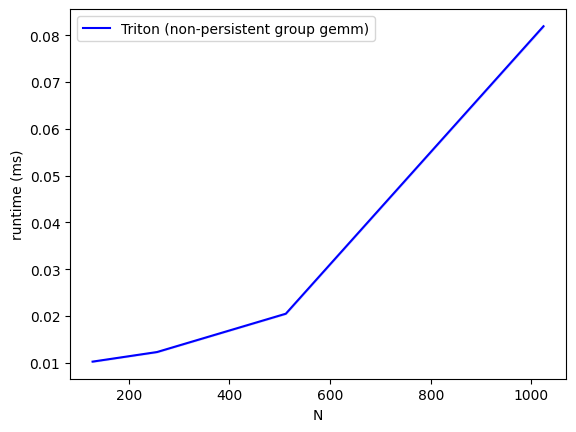

non-persistent-group-gemm-square:
        N  Triton (non-persistent group gemm)
0   128.0                            0.010240
1   256.0                            0.012288
2   512.0                            0.020480
3  1024.0                            0.081920


In [6]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=WORKLOAD_NS,                       # 128, 256, 512, 1024
        line_arg="provider",
        line_vals=["triton"],
        line_names=["Triton (non-persistent group gemm)"],
        styles=[("blue", "-")],
        ylabel="runtime (ms)",
        plot_name="non-persistent-group-gemm-square",
        args={},
    )
)
def benchmark_non_persistent(N, provider):
    group_size = WORKLOAD_GROUP_SIZE
    gA, gB = _make_group([N] * group_size, [N] * group_size, [N] * group_size)

    cfg = best_cfg_by_N[N]
    BM, BN, BK = cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"], cfg["BLOCK_SIZE_K"]
    NW, NS = cfg["num_warps"], cfg["num_stages"]

    args = _prepare_launch_args(gA, gB, BM, BN)
    quantiles = [0.5, 0.2, 0.8]
    return triton.testing.do_bench(
        lambda: _launch(args, BM, BN, BK, NW, NS),
        quantiles=quantiles,
    )


benchmark_non_persistent.run(show_plots=True, print_data=True)


### Persistent group GEMM

In [7]:
@triton.jit
def persistent_group_gemm(
    group_a_ptrs,            # [G]   int64 base addresses of A_g
    group_b_ptrs,            # [G]
    group_c_ptrs,            # [G]
    group_gemm_sizes_ptr,    # [G, 3] (M_g, N_g, K_g)
    g_lds_ptr,               # [G, 3] (lda_g, ldb_g, ldc_g)
    group_size,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
):
    block_id = tl.program_id(0)

    # Each CTA walks all groups in order; within a group it claims every
    # NUM_SMS-th (M, N) tile starting from `block_id`. All CTAs finish group g
    # before moving on to g+1 — load-imbalanced when group sizes vary.
    for g in tl.range(group_size):
        local_a_ptr = tl.load(group_a_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_b_ptr = tl.load(group_b_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_c_ptr = tl.load(group_c_ptrs + g).to(tl.pointer_type(tl.bfloat16))

        m = tl.load(group_gemm_sizes_ptr + g * 3)
        n = tl.load(group_gemm_sizes_ptr + g * 3 + 1)
        k = tl.load(group_gemm_sizes_ptr + g * 3 + 2)

        lda = tl.load(g_lds_ptr + g * 3)
        ldb = tl.load(g_lds_ptr + g * 3 + 1)
        ldc = tl.load(g_lds_ptr + g * 3 + 2)

        num_tiles_m = tl.cdiv(m, BLOCK_SIZE_M)
        num_tiles_n = tl.cdiv(n, BLOCK_SIZE_N)
        num_tiles = num_tiles_m * num_tiles_n

        offs_k = tl.arange(0, BLOCK_SIZE_K)

        for tile_id in tl.range(block_id, num_tiles, NUM_SMS):
            tile_m_idx = tile_id // num_tiles_n
            tile_n_idx = tile_id % num_tiles_n

            m_offs = tile_m_idx * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
            n_offs = tile_n_idx * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)

            accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
            for k_start in range(0, k, BLOCK_SIZE_K):
                k_offs = k_start + offs_k
                k_mask = k_offs < k
                a_mask = (m_offs[:, None] < m) & k_mask[None, :]
                b_mask = k_mask[:, None] & (n_offs[None, :] < n)
                a_tile = tl.load(
                    local_a_ptr + m_offs[:, None] * lda + k_offs[None, :],
                    mask=a_mask, other=0.0,
                )
                b_tile = tl.load(
                    local_b_ptr + k_offs[:, None] * ldb + n_offs[None, :],
                    mask=b_mask, other=0.0,
                )
                accumulator = tl.dot(a_tile, b_tile, acc=accumulator)

            c_mask = (m_offs[:, None] < m) & (n_offs[None, :] < n)
            tl.store(
                local_c_ptr + m_offs[:, None] * ldc + n_offs[None, :],
                accumulator.to(tl.bfloat16),
                mask=c_mask,
            )

#### Wrapper

Notice that the kernel signature dropped `group_prefix_blks_ptr` — there's no prefix sum to compute on the host, and the grid is fixed at `(NUM_SMS,)`. That makes this wrapper noticeably simpler than `non_persistent_group_gemm_fn`, and it means the persistent kernel is a clean fit for `@triton.autotune` (the meta-parameters no longer affect the launch grid).

In [8]:
def persistent_group_gemm_fn(
    group_A,
    group_B,
    BLOCK_SIZE_M: int = 64,
    BLOCK_SIZE_N: int = 64,
    BLOCK_SIZE_K: int = 32,
    num_warps: int = 4,
    num_stages: int = 3,
):
    """Dispatch wrapper for the basic persistent group GEMM kernel."""
    assert len(group_A) == len(group_B)
    G = len(group_A)
    DEVICE = group_A[0].device
    NUM_SMS = torch.cuda.get_device_properties(DEVICE).multi_processor_count

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []

    for A, B in zip(group_A, group_B):
        assert A.shape[1] == B.shape[0], f"K mismatch: {A.shape} vs {B.shape}"
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]

    d_a_ptrs = torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64)
    d_b_ptrs = torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64)
    d_c_ptrs = torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64)
    d_g_sizes = torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32)
    d_g_lds = torch.tensor(g_lds, device=DEVICE, dtype=torch.int32)

    persistent_group_gemm[(NUM_SMS,)](
        d_a_ptrs, d_b_ptrs, d_c_ptrs,
        d_g_sizes, d_g_lds,
        G,
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BLOCK_SIZE_M,
        BLOCK_SIZE_N=BLOCK_SIZE_N,
        BLOCK_SIZE_K=BLOCK_SIZE_K,
        num_warps=num_warps,
        num_stages=num_stages,
    )
    return group_C


#### Correctness check

In [9]:
def _check(fn, group_A, group_B, label, atol=2e-2, rtol=2e-2):
    """Generic correctness check — `fn(group_A, group_B) -> list[Tensor]`."""
    tri_out = fn(group_A, group_B)
    ref_out = [torch.matmul(a.float(), b.float()).to(a.dtype)
               for a, b in zip(group_A, group_B)]
    for t, r in zip(tri_out, ref_out):
        torch.testing.assert_close(t, r, atol=atol, rtol=rtol)
    print(f"[{label}] OK ({len(group_A)} problems)")


#### Correctness — basic persistent on diverse workloads

In [10]:
torch.manual_seed(0)

WORKLOADS = [
    # label,           ms,                    ns,                    ks
    ("aligned",        [1024, 512, 256, 128], [1024, 512, 256, 128], [1024, 512, 256, 128]),
    ("irregular",      [1000, 513, 200, 99 ], [1000, 257, 200, 99 ], [1000, 513, 200, 99 ]),
    ("mixed",          [1024, 512, 256, 128], [99,   257, 200, 17 ], [1024, 512, 256, 128]),
    ("heterogeneous",  [2048, 64,  1024, 7 ], [2048, 64,  1024, 7 ], [2048, 64,  1024, 7 ]),
]

for label, ms, ns, ks in WORKLOADS:
    gA, gB = _make_group(ms, ns, ks)
    _check(persistent_group_gemm_fn, gA, gB, f"basic / {label}")


[basic / aligned] OK (4 problems)
[basic / irregular] OK (4 problems)
[basic / mixed] OK (4 problems)
[basic / heterogeneous] OK (4 problems)


#### Autotune persistent kernels — per workload

Same per-workload sweep approach as the non-persistent autotune: each kernel is tuned **independently for every `N` in `WORKLOAD_NS`**, and the winning config is stored in a dict keyed by `N`. The final benchmark then looks up the config that matches the workload it's measuring.

One nice property of the persistent kernels: the launch grid is fixed at `(NUM_SMS,)` regardless of `(BM, BN)`, so we don't need to rebuild any device-side metadata between configs — `_prepare_persistent_args` runs once per workload and is reused across the whole config sweep. We also add `NUM_SMS` itself as a tuning axis (`{84, device_num_sms, 128}`), because for the persistent kernels the right grid size depends on the workload.


In [11]:
def _prepare_persistent_args(group_A, group_B):
    """Build device-side metadata for the persistent kernels.

    Independent of (BM, BN, NUM_SMS) — the launch grid is decided at call
    time, not by output shape.
    """
    G = len(group_A)
    DEVICE = group_A[0].device

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []
    all_K_div_16, all_N_div_16 = True, True

    for A, B in zip(group_A, group_B):
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]
        all_K_div_16 &= (K % 16 == 0)
        all_N_div_16 &= (N % 16 == 0)

    return dict(
        d_a_ptrs=torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64),
        d_b_ptrs=torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64),
        d_c_ptrs=torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64),
        d_g_sizes=torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32),
        d_g_lds=torch.tensor(g_lds, device=DEVICE, dtype=torch.int32),
        G=G,
        all_K_div_16=all_K_div_16,
        all_N_div_16=all_N_div_16,
        group_C=group_C,
    )


def _launch_persistent(args, BM, BN, BK, num_warps, num_stages, NUM_SMS):
    persistent_group_gemm[(NUM_SMS,)](
        args["d_a_ptrs"], args["d_b_ptrs"], args["d_c_ptrs"],
        args["d_g_sizes"], args["d_g_lds"],
        args["G"],
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK,
        num_warps=num_warps, num_stages=num_stages,
    )


DEVICE_NUM_SMS = torch.cuda.get_device_properties(torch.device("cuda")).multi_processor_count
NUM_SMS_CANDIDATES = sorted({84, DEVICE_NUM_SMS, 128})

PERSISTENT_AUTOTUNE_CONFIGS = [
    {**cfg, "NUM_SMS": ns}
    for cfg in AUTOTUNE_CONFIGS
    for ns in NUM_SMS_CANDIDATES
]


def _sweep_persistent_per_workload(launcher, label, **launcher_kwargs):
    """Sweep PERSISTENT_AUTOTUNE_CONFIGS for each N in WORKLOAD_NS.

    Returns dict[N] -> best config. Extra launcher kwargs (e.g. COMPILE_OPT)
    are forwarded to the launcher unchanged.
    """
    print(f"Sweeping {len(PERSISTENT_AUTOTUNE_CONFIGS)} configs x "
          f"{len(WORKLOAD_NS)} workloads for {label}  "
          f"(NUM_SMS in {NUM_SMS_CANDIDATES}, device has {DEVICE_NUM_SMS})...")
    best_by_N = {}
    for N in WORKLOAD_NS:
        gA, gB = _make_group([N] * WORKLOAD_GROUP_SIZE,
                             [N] * WORKLOAD_GROUP_SIZE,
                             [N] * WORKLOAD_GROUP_SIZE)
        args = _prepare_persistent_args(gA, gB)
        results = []
        for cfg in PERSISTENT_AUTOTUNE_CONFIGS:
            BM, BN = cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"]
            BK, NW, NS = cfg["BLOCK_SIZE_K"], cfg["num_warps"], cfg["num_stages"]
            SM = cfg["NUM_SMS"]
            try:
                ms = triton.testing.do_bench(
                    lambda: launcher(args, BM, BN, BK, NW, NS, SM,
                                     **launcher_kwargs),
                    warmup=25, rep=100,
                )
                results.append((ms, cfg))
            except Exception as e:
                results.append((float("inf"), cfg, str(e)))
        results.sort(key=lambda x: x[0])
        best_ms, best_cfg, *_ = results[0]
        best_by_N[N] = best_cfg
        print(f"  N={N:4d}: best {best_ms:.4f} ms  "
              f"BM={best_cfg['BLOCK_SIZE_M']:3d} BN={best_cfg['BLOCK_SIZE_N']:3d} "
              f"BK={best_cfg['BLOCK_SIZE_K']:3d} NUM_SMS={best_cfg['NUM_SMS']:3d} "
              f"W={best_cfg['num_warps']} S={best_cfg['num_stages']}")
    return best_by_N


torch.manual_seed(0)
best_persistent_cfg_by_N = _sweep_persistent_per_workload(
    _launch_persistent, "persistent (basic)")


Sweeping 96 configs x 4 workloads for persistent (basic)  (NUM_SMS in [84, 128, 148], device has 148)...
  N= 128: best 0.0213 ms  BM= 64 BN= 64 BK= 64 NUM_SMS= 84 W=8 S=3
  N= 256: best 0.0308 ms  BM= 64 BN= 64 BK= 64 NUM_SMS=148 W=8 S=3
  N= 512: best 0.0491 ms  BM= 64 BN= 64 BK= 64 NUM_SMS= 84 W=8 S=4
  N=1024: best 0.1024 ms  BM=128 BN= 64 BK= 64 NUM_SMS=148 W=8 S=4


#### Better Persistent Scheduling

The basic persistent kernel uses **per-group** scheduling: each CTA's tile index resets to `block_id` at the start of every group, so a CTA with `block_id >= num_tiles_g` does no work in group `g`.

**Limitation**: when `num_tiles_per_group < NUM_SMS`, high-numbered CTAs idle for the whole kernel run. With 4 groups of 3 tiles each and `NUM_SMS = 5`:

```
              g=0  g=1  g=2  g=3
       t=0 |  0  |  0  |  0  |  0  |    CTA 0 does 4 tiles
       t=1 |  1  |  1  |  1  |  1  |    CTA 1 does 4 tiles
       t=2 |  2  |  2  |  2  |  2  |    CTA 2 does 4 tiles
                                        CTAs 3, 4 do 0 tiles (idle)
```

Three CTAs do 4 tiles each in sequence; the other two SMs are wasted. Max work = 4 tile-times.

The fix is a **flat tile-space** schedule: keep `global_tile_idx` monotonic across groups. Treat the union of all groups' tiles as one flat sequence of length `sum(num_tiles_g)`; each CTA walks it by stride `NUM_SMS`. After processing a tile in group `g`, advance by `NUM_SMS` — if the new index lands past group `g`'s range, the inner while-loop exits and group `g+1` picks up wherever `global_tile_idx` is. Same total work, but spread across all CTAs:

```
              g=0  g=1  g=2  g=3
       t=0 |  0  |  3  |  1  |  4  |    every CTA gets work
       t=1 |  1  |  4  |  2  |  0  |    max work = 3 tiles
       t=2 |  2  |  0  |  3  |  1  |
```

All 5 SMs busy → wall time 3 tile-times instead of 4. Same code in the inner tile body — only the outer scheduling loop differs.

In [12]:
@triton.jit
def persistent_group_gemm_schedule(
    group_a_ptrs,            # [G]   int64 base addresses of A_g
    group_b_ptrs,            # [G]
    group_c_ptrs,            # [G]
    group_gemm_sizes_ptr,    # [G, 3] (M_g, N_g, K_g)
    g_lds_ptr,               # [G, 3] (lda_g, ldb_g, ldc_g)
    group_size,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    COMPILE_OPT: tl.constexpr,
):
    """Flat tile-space persistent group GEMM.

    `COMPILE_OPT` (constexpr): when True, applies `tl.multiple_of(_, [16, 16])`
    hints to the A/B/C pointer tensors in the inner loop. The wrapper sets
    this to True only when every (lda, ldb, ldc) in the batch is a multiple
    of 16 — otherwise the hint would be a false promise and could cause
    misaligned vector loads / undefined behavior.
    """
    block_id = tl.program_id(0)

    # Flat tile-space schedule: global_tile_idx monotonic across groups.
    global_tile_idx = block_id
    global_group_start_tile_idx = 0

    for g in range(group_size):
        local_a_ptr = tl.load(group_a_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_b_ptr = tl.load(group_b_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_c_ptr = tl.load(group_c_ptrs + g).to(tl.pointer_type(tl.bfloat16))

        m = tl.load(group_gemm_sizes_ptr + g * 3)
        n = tl.load(group_gemm_sizes_ptr + g * 3 + 1)
        k = tl.load(group_gemm_sizes_ptr + g * 3 + 2)

        lda = tl.load(g_lds_ptr + g * 3)
        ldb = tl.load(g_lds_ptr + g * 3 + 1)
        ldc = tl.load(g_lds_ptr + g * 3 + 2)

        num_tiles_m = tl.cdiv(m, BLOCK_SIZE_M)
        num_tiles_n = tl.cdiv(n, BLOCK_SIZE_N)
        num_tiles = num_tiles_m * num_tiles_n
        global_group_end_tile_idx = global_group_start_tile_idx + num_tiles

        while global_tile_idx < global_group_end_tile_idx:
            local_tile_idx = global_tile_idx - global_group_start_tile_idx
            local_tile_m = local_tile_idx // num_tiles_n
            local_tile_n = local_tile_idx % num_tiles_n

            offs_m = local_tile_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
            offs_n = local_tile_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)

            accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
            for k_start in range(0, k, BLOCK_SIZE_K):
                offs_k = k_start + tl.arange(0, BLOCK_SIZE_K)
                k_mask = offs_k < k
                a_mask = (offs_m[:, None] < m) & k_mask[None, :]
                b_mask = k_mask[:, None] & (offs_n[None, :] < n)

                a_ptrs = local_a_ptr + offs_m[:, None] * lda + offs_k[None, :]
                b_ptrs = local_b_ptr + offs_k[:, None] * ldb + offs_n[None, :]
                if COMPILE_OPT:
                    tl.multiple_of(a_ptrs, [16, 16])
                    tl.multiple_of(b_ptrs, [16, 16])

                a_tile = tl.load(a_ptrs, mask=a_mask, other=0.0)
                b_tile = tl.load(b_ptrs, mask=b_mask, other=0.0)
                accumulator = tl.dot(a_tile, b_tile, acc=accumulator)

            c_ptrs = local_c_ptr + offs_m[:, None] * ldc + offs_n[None, :]
            if COMPILE_OPT:
                tl.multiple_of(c_ptrs, [16, 16])
            c_mask = (offs_m[:, None] < m) & (offs_n[None, :] < n)
            tl.store(c_ptrs, accumulator.to(tl.bfloat16), mask=c_mask)

            global_tile_idx += NUM_SMS

        global_group_start_tile_idx += num_tiles


#### Wrapper

In [13]:
def persistent_group_gemm_schedule_fn(
    group_A,
    group_B,
    BLOCK_SIZE_M: int = 64,
    BLOCK_SIZE_N: int = 64,
    BLOCK_SIZE_K: int = 32,
    num_warps: int = 4,
    num_stages: int = 3,
    NUM_SMS: int = None,
    compile_opt: bool = True,
):
    """Wrapper for the flat-tile-space persistent kernel.

    `compile_opt=True` requests the `tl.multiple_of(_, [16, 16])` hints —
    but it's only honored if every (lda, ldb, ldc) in the batch is a
    multiple of 16. Otherwise we silently fall back to no hint (so the
    wrapper is safe to call on any shape)."""
    assert len(group_A) == len(group_B)
    G = len(group_A)
    DEVICE = group_A[0].device
    if NUM_SMS is None:
        NUM_SMS = torch.cuda.get_device_properties(DEVICE).multi_processor_count

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []
    all_strides_div_16 = True
    for A, B in zip(group_A, group_B):
        assert A.shape[1] == B.shape[0]
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        lda_g, ldb_g, ldc_g = A.stride(0), B.stride(0), C.stride(0)
        g_lds += [lda_g, ldb_g, ldc_g]
        if (lda_g % 16) or (ldb_g % 16) or (ldc_g % 16):
            all_strides_div_16 = False

    use_compile_opt = compile_opt and all_strides_div_16

    d_a_ptrs = torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64)
    d_b_ptrs = torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64)
    d_c_ptrs = torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64)
    d_g_sizes = torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32)
    d_g_lds = torch.tensor(g_lds, device=DEVICE, dtype=torch.int32)

    persistent_group_gemm_schedule[(NUM_SMS,)](
        d_a_ptrs, d_b_ptrs, d_c_ptrs,
        d_g_sizes, d_g_lds,
        G,
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BLOCK_SIZE_M,
        BLOCK_SIZE_N=BLOCK_SIZE_N,
        BLOCK_SIZE_K=BLOCK_SIZE_K,
        COMPILE_OPT=use_compile_opt,
        num_warps=num_warps,
        num_stages=num_stages,
    )
    return group_C


def _launch_persistent_schedule(args, BM, BN, BK, num_warps, num_stages,
                                 NUM_SMS, COMPILE_OPT=False):
    persistent_group_gemm_schedule[(NUM_SMS,)](
        args["d_a_ptrs"], args["d_b_ptrs"], args["d_c_ptrs"],
        args["d_g_sizes"], args["d_g_lds"],
        args["G"],
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK,
        COMPILE_OPT=COMPILE_OPT,
        num_warps=num_warps, num_stages=num_stages,
    )


### TMA support (SM90+)

Adapt `persistent_group_gemm_schedule` to use the TMA engine via `tl.make_tensor_descriptor`, mirroring the TMA kernel in [08-grouped-gemm.ipynb](08-grouped-gemm.ipynb). The wrapper auto-dispatches: on SM≥90 the public name `persistent_group_gemm_schedule_fn` (and `_launch_persistent_schedule`) is rebound to the TMA variant, so all downstream correctness checks, autotuning and benchmarks transparently use TMA. On older GPUs (A100/SM80, etc.) the original non-TMA path is preserved.


In [14]:
from typing import Optional


@triton.jit
def persistent_group_gemm_schedule_tma(
    group_a_ptrs,            # [G]   int64 base addresses of A_g
    group_b_ptrs,            # [G]
    group_c_ptrs,            # [G]
    group_gemm_sizes_ptr,    # [G, 3] (M_g, N_g, K_g)
    g_lds_ptr,               # [G, 3] (lda_g, ldb_g, ldc_g)
    group_size,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
):
    """Flat tile-space persistent group GEMM, TMA edition.

    Same outer schedule as `persistent_group_gemm_schedule` (each CTA walks
    a flat tile space, stride NUM_SMS, monotonic across groups). A, B, C
    are accessed through TMA tensor descriptors — bounds-checking and
    vectorization are handled by the engine, so the per-element masks and
    `tl.multiple_of` hints from the non-TMA kernel are gone.
    """
    block_id = tl.program_id(0)

    global_tile_idx = block_id
    global_group_start_tile_idx = 0

    for g in range(group_size):
        local_a_ptr = tl.load(group_a_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_b_ptr = tl.load(group_b_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_c_ptr = tl.load(group_c_ptrs + g).to(tl.pointer_type(tl.bfloat16))

        m = tl.load(group_gemm_sizes_ptr + g * 3)
        n = tl.load(group_gemm_sizes_ptr + g * 3 + 1)
        k = tl.load(group_gemm_sizes_ptr + g * 3 + 2)

        lda = tl.load(g_lds_ptr + g * 3)
        ldb = tl.load(g_lds_ptr + g * 3 + 1)
        ldc = tl.load(g_lds_ptr + g * 3 + 2)

        num_tiles_m = tl.cdiv(m, BLOCK_SIZE_M)
        num_tiles_n = tl.cdiv(n, BLOCK_SIZE_N)
        num_tiles = num_tiles_m * num_tiles_n
        global_group_end_tile_idx = global_group_start_tile_idx + num_tiles

        # Skip descriptor construction entirely if this CTA has no tiles in g.
        if global_tile_idx < global_group_end_tile_idx:
            a_desc = tl.make_tensor_descriptor(
                local_a_ptr,
                shape=[m, k],
                strides=[lda, 1],
                block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K],
            )
            b_desc = tl.make_tensor_descriptor(
                local_b_ptr,
                shape=[k, n],
                strides=[ldb, 1],
                block_shape=[BLOCK_SIZE_K, BLOCK_SIZE_N],
            )
            c_desc = tl.make_tensor_descriptor(
                local_c_ptr,
                shape=[m, n],
                strides=[ldc, 1],
                block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N],
            )

            while global_tile_idx < global_group_end_tile_idx:
                local_tile_idx = global_tile_idx - global_group_start_tile_idx
                local_tile_m = local_tile_idx // num_tiles_n
                local_tile_n = local_tile_idx % num_tiles_n

                offs_m = local_tile_m * BLOCK_SIZE_M
                offs_n = local_tile_n * BLOCK_SIZE_N

                accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
                for k_start in range(0, k, BLOCK_SIZE_K):
                    a = a_desc.load([offs_m, k_start])
                    b = b_desc.load([k_start, offs_n])
                    accumulator = tl.dot(a, b, acc=accumulator)

                c_desc.store([offs_m, offs_n], accumulator.to(tl.bfloat16))

                global_tile_idx += NUM_SMS

        global_group_start_tile_idx += num_tiles


# TMA descriptors live in a side allocation managed by the runtime. Triton
# asks for that buffer through a user-installed allocator — install once.
_tma_allocator_installed = False

def _ensure_tma_allocator():
    global _tma_allocator_installed
    if _tma_allocator_installed:
        return
    def _alloc_fn(size: int, alignment: int, stream: Optional[int]):
        return torch.empty(size, device="cuda", dtype=torch.int8)
    triton.set_allocator(_alloc_fn)
    _tma_allocator_installed = True


def persistent_group_gemm_schedule_tma_fn(
    group_A,
    group_B,
    BLOCK_SIZE_M: int = 128,
    BLOCK_SIZE_N: int = 128,
    BLOCK_SIZE_K: int = 64,
    num_warps: int = 4,
    num_stages: int = 3,
    NUM_SMS: int = None,
    compile_opt: bool = True,  # accepted for signature parity; ignored under TMA
):
    """TMA wrapper. Mirrors `persistent_group_gemm_schedule_fn`'s signature
    so it can drop into the same call sites. `compile_opt` is accepted but
    has no effect — the TMA engine handles vector alignment internally."""
    assert supports_tma(), "TMA wrapper requires SM>=90"
    _ensure_tma_allocator()

    assert len(group_A) == len(group_B)
    G = len(group_A)
    DEVICE = group_A[0].device
    if NUM_SMS is None:
        NUM_SMS = torch.cuda.get_device_properties(DEVICE).multi_processor_count

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []
    for A, B in zip(group_A, group_B):
        assert A.shape[1] == B.shape[0]
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]

    d_a_ptrs = torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64)
    d_b_ptrs = torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64)
    d_c_ptrs = torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64)
    d_g_sizes = torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32)
    d_g_lds = torch.tensor(g_lds, device=DEVICE, dtype=torch.int32)

    persistent_group_gemm_schedule_tma[(NUM_SMS,)](
        d_a_ptrs, d_b_ptrs, d_c_ptrs,
        d_g_sizes, d_g_lds,
        G,
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BLOCK_SIZE_M,
        BLOCK_SIZE_N=BLOCK_SIZE_N,
        BLOCK_SIZE_K=BLOCK_SIZE_K,
        num_warps=num_warps,
        num_stages=num_stages,
    )
    return group_C


def _launch_persistent_schedule_tma(args, BM, BN, BK, num_warps, num_stages,
                                     NUM_SMS, COMPILE_OPT=False):
    """Drop-in replacement for `_launch_persistent_schedule` that calls the
    TMA kernel. `COMPILE_OPT` is accepted but ignored."""
    _ensure_tma_allocator()
    persistent_group_gemm_schedule_tma[(NUM_SMS,)](
        args["d_a_ptrs"], args["d_b_ptrs"], args["d_c_ptrs"],
        args["d_g_sizes"], args["d_g_lds"],
        args["G"],
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK,
        num_warps=num_warps, num_stages=num_stages,
    )


# Auto-dispatch: on SM>=90 rebind the public names so every subsequent
# correctness check / autotune / benchmark transparently uses TMA.
if supports_tma():
    persistent_group_gemm_schedule_fn = persistent_group_gemm_schedule_tma_fn
    _launch_persistent_schedule = _launch_persistent_schedule_tma
    print("TMA supported — persistent_group_gemm_schedule_fn now dispatches to the TMA kernel.")
else:
    print("TMA NOT supported (SM<90) — keeping the non-TMA persistent_group_gemm_schedule_fn.")


TMA supported — persistent_group_gemm_schedule_fn now dispatches to the TMA kernel.


#### TMA stride-alignment requirement

The TMA engine requires the **global-memory row stride of every tensor it accesses to be a multiple of 16 bytes** — equivalently, a multiple of `16 / element_size` *elements* (8 for bf16, 16 for fp8/uint8). The base pointer must also be 16-byte aligned, which `torch.empty` / `torch.randn` give us for free.

For this bf16 group GEMM, the row strides are `A.stride(0) = K`, `B.stride(0) = N`, `C.stride(0) = N`. So every group must satisfy **`K % 8 == 0` and `N % 8 == 0`**. Workloads such as `K=99`, `N=257`, or `K=17` violate this — TMA mis-indexes silently (no error raised) and you get ~98% mismatched elements with magnitudes far outside the expected range.

**TODO**: support arbitrary shapes via host-side padding — allocate `K_pad = round_up(K, 8)`, `N_pad = round_up(N, 8)` tensors, copy the unpadded values in, run the kernel on the padded shape, then slice the output back. Until that lands, the correctness cell below skips non-aligned workloads when TMA is the active dispatch path.


#### Correctness

In [15]:
torch.manual_seed(0)


def _tma_row_strides_aligned(ms, ns, ks, elem_bytes=2):
    """True iff every (M, K) / (K, N) / (M, N) row stride is a multiple of
    16 bytes (TMA prerequisite). For bf16 (2 B/elem) that's an 8-element grid."""
    align_elems = 16 // elem_bytes
    return all(k % align_elems == 0 and n % align_elems == 0
               for n, k in zip(ns, ks))


_TMA_ACTIVE = supports_tma()

for label, ms, ns, ks in WORKLOADS:
    if _TMA_ACTIVE and not _tma_row_strides_aligned(ms, ns, ks):
        print(f"⏭️  skipped {label}: row strides not 16B-aligned and TMA is the "
              f"active dispatch. TMA mis-indexes silently on misaligned strides "
              f"(see markdown above). TODO: pad host inputs to support this.")
        continue
    gA, gB = _make_group(ms, ns, ks)
    # Default: compile_opt=True. Wrapper silently disables it if strides
    # aren't 16-aligned (non-TMA path); aligned workloads pass under both.
    _check(persistent_group_gemm_schedule_fn, gA, gB, f"schedule (auto) / {label}")
    # Force compile_opt=False to also verify the no-hint path:
    _check(
        lambda a, b: persistent_group_gemm_schedule_fn(a, b, compile_opt=False),
        gA, gB,
        f"schedule (compile_opt=False) / {label}",
    )


[schedule (auto) / aligned] OK (4 problems)
[schedule (compile_opt=False) / aligned] OK (4 problems)
⏭️  skipped irregular: row strides not 16B-aligned and TMA is the active dispatch. TMA mis-indexes silently on misaligned strides (see markdown above). TODO: pad host inputs to support this.
⏭️  skipped mixed: row strides not 16B-aligned and TMA is the active dispatch. TMA mis-indexes silently on misaligned strides (see markdown above). TODO: pad host inputs to support this.
⏭️  skipped heterogeneous: row strides not 16B-aligned and TMA is the active dispatch. TMA mis-indexes silently on misaligned strides (see markdown above). TODO: pad host inputs to support this.


#### Autotune

In [16]:
torch.manual_seed(0)

best_persistent_schedule_cfg_by_N = _sweep_persistent_per_workload(
    _launch_persistent_schedule, "schedule (COMPILE_OPT=False)",
    COMPILE_OPT=False,
)
if supports_tma():
    # On SM>=90 `_launch_persistent_schedule` is rebound to the TMA wrapper,
    # which ignores COMPILE_OPT. The COMPILE_OPT=True sweep would search the
    # same kernel and differ only by measurement noise -- skip it.
    print("TMA active -- skipping COMPILE_OPT=True sweep (would duplicate the False sweep).")
    best_persistent_schedule_co_cfg_by_N = best_persistent_schedule_cfg_by_N
else:
    best_persistent_schedule_co_cfg_by_N = _sweep_persistent_per_workload(
        _launch_persistent_schedule, "schedule (COMPILE_OPT=True)",
        COMPILE_OPT=True,
    )


Sweeping 96 configs x 4 workloads for schedule (COMPILE_OPT=False)  (NUM_SMS in [84, 128, 148], device has 148)...
  N= 128: best 0.0117 ms  BM= 64 BN=128 BK= 64 NUM_SMS=148 W=4 S=3
  N= 256: best 0.0123 ms  BM= 64 BN= 64 BK= 64 NUM_SMS=148 W=4 S=4
  N= 512: best 0.0143 ms  BM=128 BN= 64 BK= 64 NUM_SMS=128 W=8 S=4
  N=1024: best 0.0276 ms  BM=128 BN=128 BK= 64 NUM_SMS=128 W=4 S=4
TMA active -- skipping COMPILE_OPT=True sweep (would duplicate the False sweep).


### Benchmark — final 4-kernel comparison

Same axes as 08-grouped-gemm's `benchmark_square_matrices` for direct comparison: `N in {128, 256, 512, 1024}`, `group_size = 4`, square `N x N x N` matrices, runtime in ms (lower = better).

**Per-workload autotuning:** each kernel was tuned independently for every `N` in `WORKLOAD_NS` in the autotune cells above; the benchmark below looks up `best_*_cfg_by_N[N]` for each point. This is what 08-grouped-gemm's `@triton.autotune` does implicitly (key=`['group_size']`, but with the kernel's own runtime cache hitting the actual `(M, N, K)` shapes via specialization). Without the per-workload lookup, the line for each kernel reflects a single compromise config rather than the kernel's actual peak at each size.

Four kernels, in order of optimizations applied:
1. **non-persistent** — baseline, one CTA per output tile
2. **persistent (basic)** — fixed `NUM_SMS` grid, per-group scheduling
3. **persistent + flat schedule** — flat tile-space schedule across groups (loads spread across all SMs)
4. **persistent + flat schedule + compile_opt** — same as 3, plus `tl.multiple_of` hints on the pointer tensors


TMA active -- dropping `persistent_schedule_comp` (would duplicate `persistent_schedule`).


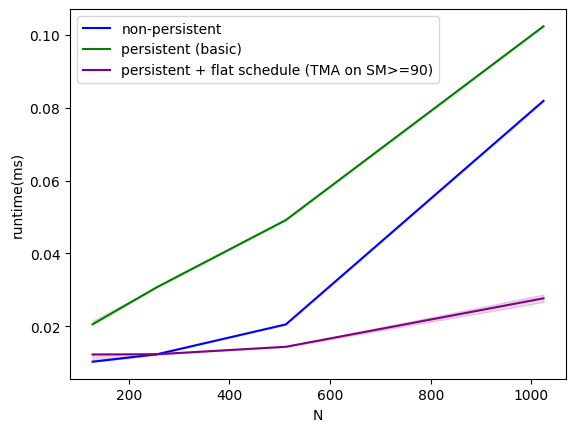

group-gemm-4kernel-runtime:
        N  non-persistent  persistent (basic)  persistent + flat schedule (TMA on SM>=90)
0   128.0        0.010240            0.020512                                    0.012224
1   256.0        0.012288            0.030720                                    0.012288
2   512.0        0.020480            0.049152                                    0.014336
3  1024.0        0.081920            0.102400                                    0.027648


In [17]:
# On B200 (or any SM>=90) `_launch_persistent_schedule` is rebound to the TMA
# wrapper, which ignores COMPILE_OPT entirely. So `persistent_schedule_comp`
# would benchmark the *same* TMA kernel as `persistent_schedule` -- drop it
# when TMA is active to avoid a duplicate line / wasted autotune.
if supports_tma():
    _BF16_LINE_VALS  = ["non_persistent", "persistent", "persistent_schedule"]
    _BF16_LINE_NAMES = ["non-persistent",
                        "persistent (basic)",
                        "persistent + flat schedule (TMA on SM>=90)"]
    _BF16_STYLES     = [("blue", "-"), ("green", "-"), ("purple", "-")]
    print("TMA active -- dropping `persistent_schedule_comp` (would duplicate `persistent_schedule`).")
else:
    _BF16_LINE_VALS  = ["non_persistent", "persistent",
                        "persistent_schedule", "persistent_schedule_comp"]
    _BF16_LINE_NAMES = ["non-persistent",
                        "persistent (basic)",
                        "persistent + flat schedule",
                        "persistent + flat schedule + compile_opt"]
    _BF16_STYLES     = [("blue", "-"), ("green", "-"), ("purple", "-"), ("red", "-")]


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=WORKLOAD_NS,                       # 128, 256, 512, 1024
        line_arg="provider",
        line_vals=_BF16_LINE_VALS,
        line_names=_BF16_LINE_NAMES,
        styles=_BF16_STYLES,
        ylabel="runtime(ms)",
        plot_name="group-gemm-4kernel-runtime",
        args={},
    )
)
def benchmark_four(N, provider):
    group_size = WORKLOAD_GROUP_SIZE
    gA, gB = _make_group([N] * group_size, [N] * group_size, [N] * group_size)
    quantiles = [0.5, 0.2, 0.8]

    if provider == "non_persistent":
        cfg = best_cfg_by_N[N]
        args = _prepare_launch_args(gA, gB,
                                    cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"])
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: _launch(args,
                            cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"],
                            cfg["BLOCK_SIZE_K"],
                            cfg["num_warps"], cfg["num_stages"]),
            quantiles=quantiles,
        )

    elif provider == "persistent":
        cfg = best_persistent_cfg_by_N[N]
        args = _prepare_persistent_args(gA, gB)
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: _launch_persistent(
                args, cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"], cfg["BLOCK_SIZE_K"],
                cfg["num_warps"], cfg["num_stages"], cfg["NUM_SMS"]),
            quantiles=quantiles,
        )

    elif provider == "persistent_schedule":
        cfg = best_persistent_schedule_cfg_by_N[N]
        args = _prepare_persistent_args(gA, gB)
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: _launch_persistent_schedule(
                args, cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"], cfg["BLOCK_SIZE_K"],
                cfg["num_warps"], cfg["num_stages"], cfg["NUM_SMS"],
                COMPILE_OPT=False),
            quantiles=quantiles,
        )

    elif provider == "persistent_schedule_comp":
        cfg = best_persistent_schedule_co_cfg_by_N[N]
        args = _prepare_persistent_args(gA, gB)
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: _launch_persistent_schedule(
                args, cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"], cfg["BLOCK_SIZE_K"],
                cfg["num_warps"], cfg["num_stages"], cfg["NUM_SMS"],
                COMPILE_OPT=True),
            quantiles=quantiles,
        )

    return ms, min_ms, max_ms


benchmark_four.run(show_plots=True, print_data=True)


## Block Scaled Quantized Group GEMM

We now extend the persistent group GEMM to support **block-scaled quantization**: each operand is stored in a low-precision microscaling format (fp4 / fp8) together with a coarse per-block scale tensor that recovers the dynamic range at the dot-product. Same scheme as `10-block-scaled-matmul.ipynb`, lifted into the multi-group setting.

### Per-group tensor shapes

For each group `g` (sizes `(M_g, N_g, K_g)`), the kernel sees four data tensors and two scale tensors:

| Tensor    | Logical shape           | Physical storage                                | Element type                      |
|-----------|-------------------------|--------------------------------------------------|-----------------------------------|
| `A_g`     | `[M_g, K_g]`            | `[M_g, K_g // ELEM_PER_BYTE_A]`                  | `uint8` (fp4 packed) or `float8_e4m3` |
| `B_g`     | `[N_g, K_g]` *(B is pre-transposed: row index = N)* | `[N_g, K_g // ELEM_PER_BYTE_B]` | `uint8` (fp4 packed) or `float8_e4m3` |
| `C_g`     | `[M_g, N_g]`            | `[M_g, N_g]`                                     | `bfloat16` (fixed output dtype)   |
| `A_scale` | `[M_g, K_g // VEC_SIZE]`| `[M_g // 128, K_g // VEC_SIZE // 4, 32, 4, 4]` (preshuffled, natural) → `[1, M_g // 128, K_g // VEC_SIZE // 4, 2, 256]` (TMA-required view) | `float8_e4m3` (nvfp4) or `uint8` (e8m0, mx*) |
| `B_scale` | `[N_g, K_g // VEC_SIZE]`| `[N_g // 128, K_g // VEC_SIZE // 4, 32, 4, 4]` (preshuffled, natural) → `[1, N_g // 128, K_g // VEC_SIZE // 4, 2, 256]` (TMA-required view) | `float8_e4m3` (nvfp4) or `uint8` (e8m0, mx*) |

> **Scale view is a TMA requirement, not a re-layout.** TMA tensor descriptors require the *innermost* block dimension to span at least 16 bytes (see the alignment note in [#### TMA stride-alignment requirement](#)). The natural-5D `[…, 4]` last dim is only 4 fp8 bytes — invalid. The `[1, …, 2, 256]` view describes **the same physical memory** (same bytes, same allocation) split as `[1, …, 2, 256]` — the perf-optimized TMA layout from 10-block-scaled-matmul. The innermost 256 fp8 elements = 256 B per TMA message gives ~16× larger payloads than the natural-5D `[…, 32, 4, 4]` (whose 4-byte inner dim violates the TMA `≥ 16 B` minimum). Host-side `_make_group_nvfp4` `.view()`s the allocated tensor into this 5D shape (no copy; `2 × 256 == 32 × 4 × 4 == 512`) before passing `data_ptr()` to the kernel; the kernel builds its TMA descriptor with the same 5D shape so the two ends agree. After the load, the kernel reshapes back to `[…, 32, 4, 4]` for the `trans(0, 3, 2, 1, 4)` + reshape that yields logical `[BM, BK / VEC]`.

The four supported formats are pinned by `(ELEM_PER_BYTE_A, ELEM_PER_BYTE_B, VEC_SIZE)`:

| Format  | EPB_A | EPB_B | VEC_SIZE | A type   | B type   | Scale type   |
|---------|-------|-------|----------|----------|----------|--------------|
| nvfp4   | 2     | 2     | 16       | fp4 e2m1 | fp4 e2m1 | fp8 e4m3     |
| mxfp4   | 2     | 2     | 32       | fp4 e2m1 | fp4 e2m1 | e8m0 (uint8) |
| mxfp8   | 1     | 1     | 32       | fp8 e4m3 | fp8 e4m3 | e8m0 (uint8) |
| mixed   | 1     | 2     | 32       | fp8 e4m3 | fp4 e2m1 | e8m0 (uint8) |

### Shape / block-size assumptions

The preshuffled scale layout and the TMA descriptors impose the following alignment constraints. They hold per group — every `(M_g, N_g, K_g)` must satisfy them.

1. **Matrix dims divisible by the scale tile.**
   - `M_g % 128 == 0` and `N_g % 128 == 0` (the `// 128` factor in the 5D scale layout).
   - `K_g % (VEC_SIZE * 4) == 0` (the `K_g // VEC_SIZE // 4` factor in the scale K axis).
2. **K divisible by `BLOCK_SIZE_K`.** No K-tail handling — the inner loop walks `cdiv(K_g, BLOCK_SIZE_K)` iterations and the TMA scale load assumes whole `rep_k` chunks.
3. **Block sizes aligned to the scale layout.**
   - `BLOCK_SIZE_M % 128 == 0` ⇒ `rep_m = BLOCK_SIZE_M // 128 ≥ 1`.
   - `BLOCK_SIZE_N % 128 == 0` ⇒ `rep_n = BLOCK_SIZE_N // 128 ≥ 1`.
   - `BLOCK_SIZE_K % (VEC_SIZE * 4) == 0` ⇒ `rep_k = BLOCK_SIZE_K // VEC_SIZE // 4 ≥ 1`.
4. **B is stored in `[N, K_packed]` (i.e., transposed relative to `A @ B`).** `ldb` is the stride along N in element-packed units. The kernel loads B as `[BN, BK_packed]` and applies `b.T` at the `tl.dot_scaled` call.
5. **Strides `lda, ldb` are in packed-element units** (`K_g // ELEM_PER_BYTE`), not logical-K units.
6. **All groups share the same `(VEC_SIZE, ELEM_PER_BYTE_A, ELEM_PER_BYTE_B)`** since these are kernel-wide `constexpr`s. Mixing formats across groups would require separate launches.


In [18]:
@triton.jit
def persistent_block_scaled_group_gemm_schedule_tma(
    group_a_ptrs,            # [G]   int64 base addresses of A_g
    group_b_ptrs,            # [G]   each b matrix is in transposed shape - [N, K]
    group_c_ptrs,            # [G]
    group_a_scale_ptrs,      # [G]   scale physical shape - [m / 128, k / vec_sz / 4, 32, 4, 4]
    group_b_scale_ptrs,
    group_gemm_sizes_ptr,    # [G, 3] (M_g, N_g, K_g)
    g_lds_ptr,               # [G, 3] (lda_g, ldb_g, ldc_g) -- lda/ldb in packed-K element units
    group_size,
    VEC_SIZE: tl.constexpr,             # 16 for nvfp4, 32 for mxfp4 / mxfp8 / mixed
    ELEM_PER_BYTE_A: tl.constexpr,      # 1 for fp8 (e4m3), 2 for fp4 (e2m1 packed)
    ELEM_PER_BYTE_B: tl.constexpr,      # same convention as ELEM_PER_BYTE_A
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    NUM_STAGES: tl.constexpr,        # software-pipeline depth for the inner K loop
    WARP_SPECIALIZE: tl.constexpr,   # split mem / MMA / vector ops into async partitions in the K loop
):
    """Flat tile-space persistent group GEMM, block-scaled + TMA edition.

    The four (ELEM_PER_BYTE_A, ELEM_PER_BYTE_B, VEC_SIZE) combinations match
    10-block-scaled-matmul.ipynb:
      - nvfp4 : (2, 2, 16)  -- both fp4 e2m1, fp8-e4m3 scales
      - mxfp4 : (2, 2, 32)  -- both fp4 e2m1, e8m0 (uint8) scales
      - mxfp8 : (1, 1, 32)  -- both fp8 e4m3, e8m0 scales
      - mixed : (1, 2, 32)  -- A fp8 e4m3, B fp4 e2m1, e8m0 scales
    Output is always bfloat16.

    Scale TMA layout: scales are physically stored in the preshuffled 5D form
    [dim // 128, K // VEC // 4, 32, 4, 4], but TMA descriptors **require the
    innermost dimension to span >= 16 bytes**. The natural-5D last dim is 4
    fp8 bytes -- invalid (\"Descriptor block shape must have at least 16 bytes
    in the last dimension\"). We describe the same memory as
      [1, dim // 128, K // VEC // 4, 2, 256]
    -- the perf-optimized view from 10-block-scaled-matmul.ipynb. The
    innermost 256 fp8 elements = 256 bytes gives one large TMA message per
    (m_chunk, k_chunk) block (vs many small 16 B messages with the natural
    [..., 32, 4, 4] split). Host-side, _make_group_nvfp4 reshapes the
    scale tensor to match this 5D view -- both describe the same physical
    memory. After load, we reshape [1, rep_m, rep_k, 2, 256] -> [rep_m,
    rep_k, 32, 4, 4] (2 * 256 == 32 * 4 * 4 == 512) and apply trans +
    reshape to recover the logical [BM, BK / VEC] 2D scale tl.dot_scaled
    expects.
    """
    # nvfp4 stores scales as fp8 e4m3; the mx* formats store e8m0 in uint8.
    SCALE_DTYPE_IS_FP8: tl.constexpr = (VEC_SIZE == 16)
    MIXED_PREC: tl.constexpr = (ELEM_PER_BYTE_A == 1 and ELEM_PER_BYTE_B == 2)

    # Hoist rep_* to top-level constexprs. If we bind them inside the runtime
    # `for g`/`if` blocks below, Triton promotes them from `constexpr[int]` to
    # `constexpr[tensor]`, which `tl.make_tensor_descriptor` rejects for
    # `block_shape` entries with:
    #   TypeError: Shape element 0 must have type `constexpr[int]`,
    #              got `constexpr[<class 'triton.language.core.tensor'>]`
    rep_m: tl.constexpr = BLOCK_SIZE_M // 128
    rep_n: tl.constexpr = BLOCK_SIZE_N // 128
    rep_k: tl.constexpr = BLOCK_SIZE_K // VEC_SIZE // 4

    block_id = tl.program_id(0)

    global_tile_idx = block_id
    global_group_start_tile_idx = 0

    for g in range(group_size):
        # Operand storage type: fp8 -> float8e4nv ; packed fp4 -> uint8 (2 nibbles / byte).
        if ELEM_PER_BYTE_A == 1:
            local_a_ptr = tl.load(group_a_ptrs + g).to(tl.pointer_type(tl.float8e4nv))
        else:
            local_a_ptr = tl.load(group_a_ptrs + g).to(tl.pointer_type(tl.uint8))
        if ELEM_PER_BYTE_B == 1:
            local_b_ptr = tl.load(group_b_ptrs + g).to(tl.pointer_type(tl.float8e4nv))
        else:
            local_b_ptr = tl.load(group_b_ptrs + g).to(tl.pointer_type(tl.uint8))
        local_c_ptr = tl.load(group_c_ptrs + g).to(tl.pointer_type(tl.bfloat16))

        # Scale storage type, chosen per format above.
        if SCALE_DTYPE_IS_FP8:
            local_a_scale_ptr = tl.load(group_a_scale_ptrs + g).to(tl.pointer_type(tl.float8e4nv))
            local_b_scale_ptr = tl.load(group_b_scale_ptrs + g).to(tl.pointer_type(tl.float8e4nv))
        else:
            local_a_scale_ptr = tl.load(group_a_scale_ptrs + g).to(tl.pointer_type(tl.uint8))
            local_b_scale_ptr = tl.load(group_b_scale_ptrs + g).to(tl.pointer_type(tl.uint8))

        m = tl.load(group_gemm_sizes_ptr + g * 3)
        n = tl.load(group_gemm_sizes_ptr + g * 3 + 1)
        k = tl.load(group_gemm_sizes_ptr + g * 3 + 2)

        lda = tl.load(g_lds_ptr + g * 3)
        ldb = tl.load(g_lds_ptr + g * 3 + 1)
        ldc = tl.load(g_lds_ptr + g * 3 + 2)

        num_tiles_m = tl.cdiv(m, BLOCK_SIZE_M)
        num_tiles_n = tl.cdiv(n, BLOCK_SIZE_N)
        num_tiles = num_tiles_m * num_tiles_n
        global_group_end_tile_idx = global_group_start_tile_idx + num_tiles

        # Skip descriptor construction entirely if this CTA has no tiles in g.
        if global_tile_idx < global_group_end_tile_idx:
            # Descriptor K extents are in *packed-element* units (k // ELEM_PER_BYTE).
            a_desc = tl.make_tensor_descriptor(
                local_a_ptr,
                shape=[m, k // ELEM_PER_BYTE_A],
                strides=[lda, 1],
                block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K // ELEM_PER_BYTE_A],
            )
            # B is stored as [N, K_packed]; load as [BN, BK_packed] and use b.T at the dot.
            b_desc = tl.make_tensor_descriptor(
                local_b_ptr,
                shape=[n, k // ELEM_PER_BYTE_B],
                strides=[ldb, 1],
                block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K // ELEM_PER_BYTE_B],
            )
            c_desc = tl.make_tensor_descriptor(
                local_c_ptr,
                shape=[m, n],
                strides=[ldc, 1],
                block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N],
            )

            # Scale TMA descriptor: 5D [1, m//128, k//VEC//4, 2, 256] -- the
            # perf-optimized view used in 10-block-scaled-matmul.ipynb.
            # Inner dim = 256 fp8 elements = 256 B per TMA message (vs only
            # 16 B for the [..., 32, 16] split). Same underlying memory
            # since 2 * 256 == 32 * 4 * 4 == 512 fp8 elements per
            # (m_chunk, k_chunk) block. Host allocates and reshapes the
            # scale tensor to match this 5D view in _make_group_nvfp4.
            # rep_m / rep_n / rep_k come from the top-level constexpr
            # bindings (Triton requires constexpr[int] for block_shape
            # entries, and that survives only outside runtime control flow).
            a_scale_desc = tl.make_tensor_descriptor(
                local_a_scale_ptr,
                shape=[1, m // 128, k // VEC_SIZE // 4, 2, 256],
                strides=[(m // 128) * (k // VEC_SIZE) * 128,
                         (k // VEC_SIZE) * 128,
                         512, 256, 1],
                block_shape=[1, rep_m, rep_k, 2, 256],
            )
            b_scale_desc = tl.make_tensor_descriptor(
                local_b_scale_ptr,
                shape=[1, n // 128, k // VEC_SIZE // 4, 2, 256],
                strides=[(n // 128) * (k // VEC_SIZE) * 128,
                         (k // VEC_SIZE) * 128,
                         512, 256, 1],
                block_shape=[1, rep_n, rep_k, 2, 256],
            )

            while global_tile_idx < global_group_end_tile_idx:
                local_tile_idx = global_tile_idx - global_group_start_tile_idx
                local_tile_m = local_tile_idx // num_tiles_n
                local_tile_n = local_tile_idx % num_tiles_n

                # M and N are never packed -- only K is.
                offs_am = local_tile_m * BLOCK_SIZE_M
                offs_bn = local_tile_n * BLOCK_SIZE_N

                offs_am_scale = local_tile_m * rep_m
                offs_bn_scale = local_tile_n * rep_n

                accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
                for kk in tl.range(
                    tl.cdiv(k, BLOCK_SIZE_K),
                    num_stages=NUM_STAGES,
                    warp_specialize=WARP_SPECIALIZE,
                ):
                    k_start = kk * BLOCK_SIZE_K
                    offs_ak = k_start // ELEM_PER_BYTE_A
                    offs_bk = k_start // ELEM_PER_BYTE_B
                    a = a_desc.load([offs_am, offs_ak])            # [BM, BK_packed_A]
                    b = b_desc.load([offs_bn, offs_bk])            # [BN, BK_packed_B]

                    # Load the [1, rep_m, rep_k, 2, 256] tile, reshape to
                    # [rep_m, rep_k, 32, 4, 4] (2 * 256 == 32 * 4 * 4),
                    # then trans + reshape to the logical [BM, BK / VEC]
                    # 2D scale that tl.dot_scaled expects.
                    offs_k_scale = kk * rep_k
                    a_scale = a_scale_desc.load(
                        [0, offs_am_scale, offs_k_scale, 0, 0]
                    ).reshape(rep_m, rep_k, 32, 4, 4).trans(0, 3, 2, 1, 4).reshape(
                        BLOCK_SIZE_M, BLOCK_SIZE_K // VEC_SIZE
                    )
                    b_scale = b_scale_desc.load(
                        [0, offs_bn_scale, offs_k_scale, 0, 0]
                    ).reshape(rep_n, rep_k, 32, 4, 4).trans(0, 3, 2, 1, 4).reshape(
                        BLOCK_SIZE_N, BLOCK_SIZE_K // VEC_SIZE
                    )

                    # Element-type strings for tl.dot_scaled depend on EPB_A / EPB_B.
                    if MIXED_PREC:
                        accumulator = tl.dot_scaled(
                            a, a_scale, "e4m3", b.T, b_scale, "e2m1", acc=accumulator,
                        )
                    elif ELEM_PER_BYTE_A == 2 and ELEM_PER_BYTE_B == 2:
                        accumulator = tl.dot_scaled(
                            a, a_scale, "e2m1", b.T, b_scale, "e2m1", acc=accumulator,
                        )
                    else:
                        accumulator = tl.dot_scaled(
                            a, a_scale, "e4m3", b.T, b_scale, "e4m3", acc=accumulator,
                        )

                offs_cm = local_tile_m * BLOCK_SIZE_M
                offs_cn = local_tile_n * BLOCK_SIZE_N
                c_desc.store([offs_cm, offs_cn], accumulator.to(tl.bfloat16))

                global_tile_idx += NUM_SMS

        global_group_start_tile_idx += num_tiles


In [19]:
from triton.tools.mxfp import MXFP4Tensor

VEC_SIZE_NVFP4 = 16
ELEM_PER_BYTE_NVFP4 = 2


def _make_group_nvfp4(ms, ns, ks, device=DEVICE):
    """Build NVFP4 packed A,B (uint8) and fp8-e4m3 scales in the natural 5D
    layout [dim//128, K//VEC//4, 32, 4, 4]. Also return float32 dequantized
    copies for the validation path -- the reference matmul reads the same
    bits the kernel will read.

    Returns (per group g):
      packed_A[g]       uint8  [M, K // ELEM_PER_BYTE_A]     -- kernel input
      packed_B[g]       uint8  [N, K // ELEM_PER_BYTE_B]     -- kernel input (B is pre-transposed)
      A_scale_5d[g]     fp8    [1, M//128, K//VEC//4, 2, 256] -- kernel input (view of natural 5D)
      B_scale_5d[g]     fp8    [1, N//128, K//VEC//4, 2, 256] -- kernel input (view of natural 5D)
      A_ref_f32[g]      f32    [M, K]                         -- dequantized A
      B_ref_f32[g]      f32    [N, K]                         -- dequantized B
      A_scale_ref_f32[g] f32   same shape as A_scale_5d        -- dequantized scale
      B_scale_ref_f32[g] f32   same shape as B_scale_5d        -- dequantized scale
    """
    packed_A, packed_B, A_scale_5d, B_scale_5d = [], [], [], []
    A_ref_f32, B_ref_f32, A_scale_ref_f32, B_scale_ref_f32 = [], [], [], []
    for M, N, K in zip(ms, ns, ks):
        assert M % 128 == 0 and N % 128 == 0, f"M, N must be multiples of 128 (got {M}, {N})"
        assert K % (VEC_SIZE_NVFP4 * 4) == 0, f"K must be multiple of {VEC_SIZE_NVFP4 * 4} (got {K})"

        a_t = MXFP4Tensor(size=(M, K), device=device).random()
        b_t = MXFP4Tensor(size=(N, K), device=device).random()
        packed_A.append(a_t.to_packed_tensor(dim=1))   # uint8 [M, K//2]
        packed_B.append(b_t.to_packed_tensor(dim=1))   # uint8 [N, K//2]
        A_ref_f32.append(a_t.to(torch.float32))        # bit-exact dequantization
        B_ref_f32.append(b_t.to(torch.float32))

        # Allocate scales in the natural 5D form (matches _unpack_scale_5d
        # on the reference path), then re-view as the kernel-side 5D
        # [1, M//128, K//VEC//4, 2, 256] -- same memory, same data_ptr(),
        # just a different logical shape that mirrors the kernel's TMA
        # descriptor. The dequantized float32 reference is captured BEFORE
        # the reshape so the unpack/trans path keeps its natural shape.
        a_s_shape = (M // 128, K // VEC_SIZE_NVFP4 // 4, 32, 4, 4)
        b_s_shape = (N // 128, K // VEC_SIZE_NVFP4 // 4, 32, 4, 4)
        eps = 1e-8
        a_s = (torch.rand(a_s_shape, device=device) + eps).to(torch.float8_e4m3fn)
        b_s = (torch.rand(b_s_shape, device=device) + eps).to(torch.float8_e4m3fn)
        A_scale_ref_f32.append(a_s.to(torch.float32))  # natural-5D dequantized
        B_scale_ref_f32.append(b_s.to(torch.float32))
        # Reshape to the kernel-facing 5D view (32 * 4 * 4 == 2 * 256 == 512).
        A_scale_5d.append(a_s.view(1, M // 128, K // VEC_SIZE_NVFP4 // 4, 2, 256))
        B_scale_5d.append(b_s.view(1, N // 128, K // VEC_SIZE_NVFP4 // 4, 2, 256))
    return (packed_A, packed_B, A_scale_5d, B_scale_5d,
            A_ref_f32, B_ref_f32, A_scale_ref_f32, B_scale_ref_f32)


def _unpack_scale_5d(s5d_f32, vec_size=VEC_SIZE_NVFP4):
    """[M//128, K//VEC//4, 32, 4, 4] f32 -> [M, K] f32 with each scale value
    broadcast across VEC elements along K. Mirrors validate_block_scaled's
    unpack_scale in 10-block-scaled-matmul.ipynb."""
    num_chunk_m, num_chunk_k, _, _, _ = s5d_f32.shape
    s = s5d_f32.permute(0, 3, 2, 1, 4).reshape(num_chunk_m * 128, num_chunk_k * 4).contiguous()
    return s.repeat_interleave(vec_size, dim=1)


def _reference_matmul_nvfp4(A_f32, B_f32, A_s_f32, B_s_f32, M, N, K):
    """Float32 reference: (A * scale_A) @ (B * scale_B).T, then cast to bf16
    (matches the kernel's output dtype) and back to f32 for the compare."""
    a_s = _unpack_scale_5d(A_s_f32)[:M, :K]
    b_s = _unpack_scale_5d(B_s_f32)[:N, :K]
    return ((A_f32 * a_s) @ (B_f32 * b_s).T).to(torch.bfloat16).to(torch.float32)


In [20]:
def _prepare_block_scaled_args(packed_A, packed_B, A_scale_5d, B_scale_5d):
    """Pack per-group base ptrs, sizes, lds, and scale ptrs into device tensors.
    lda/ldb are in packed-K element units (= K // 2 for NVFP4); ldc is the bf16
    row stride."""
    G = len(packed_A)
    assert len(packed_B) == G and len(A_scale_5d) == G and len(B_scale_5d) == G
    a_addrs, b_addrs, c_addrs, sa_addrs, sb_addrs = [], [], [], [], []
    sizes, lds = [], []
    group_C = []
    for a, b, sa, sb in zip(packed_A, packed_B, A_scale_5d, B_scale_5d):
        assert a.is_contiguous() and b.is_contiguous(), "A/B must be contiguous"
        assert sa.is_contiguous() and sb.is_contiguous(), \
            "scale tensors must be contiguous (TMA scale descriptor strides assume it)"
        M, N = a.shape[0], b.shape[0]
        K = a.shape[1] * ELEM_PER_BYTE_NVFP4   # logical K (unpacked)
        C = torch.empty((M, N), device=DEVICE, dtype=torch.bfloat16)
        group_C.append(C)
        a_addrs.append(a.data_ptr())
        b_addrs.append(b.data_ptr())
        c_addrs.append(C.data_ptr())
        sa_addrs.append(sa.data_ptr())
        sb_addrs.append(sb.data_ptr())
        sizes += [M, N, K]
        lds += [a.stride(0), b.stride(0), C.stride(0)]
    return dict(
        d_a_ptrs=torch.tensor(a_addrs, device=DEVICE, dtype=torch.int64),
        d_b_ptrs=torch.tensor(b_addrs, device=DEVICE, dtype=torch.int64),
        d_c_ptrs=torch.tensor(c_addrs, device=DEVICE, dtype=torch.int64),
        d_a_scale_ptrs=torch.tensor(sa_addrs, device=DEVICE, dtype=torch.int64),
        d_b_scale_ptrs=torch.tensor(sb_addrs, device=DEVICE, dtype=torch.int64),
        d_g_sizes=torch.tensor(sizes, device=DEVICE, dtype=torch.int32),
        d_g_lds=torch.tensor(lds, device=DEVICE, dtype=torch.int32),
        G=G,
        group_C=group_C,
    )


def _launch_block_scaled(args, BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K,
                         NUM_STAGES, WARP_SPECIALIZE,
                         NUM_SMS=DEVICE_NUM_SMS, num_warps=8):
    """Launch the NVFP4 block-scaled kernel. Triton-level num_stages is
    deliberately NOT set (defaults applied)."""
    _ensure_tma_allocator()
    persistent_block_scaled_group_gemm_schedule_tma[(NUM_SMS,)](
        args["d_a_ptrs"], args["d_b_ptrs"], args["d_c_ptrs"],
        args["d_a_scale_ptrs"], args["d_b_scale_ptrs"],
        args["d_g_sizes"], args["d_g_lds"], args["G"],
        VEC_SIZE=VEC_SIZE_NVFP4,
        ELEM_PER_BYTE_A=ELEM_PER_BYTE_NVFP4,
        ELEM_PER_BYTE_B=ELEM_PER_BYTE_NVFP4,
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BLOCK_SIZE_M,
        BLOCK_SIZE_N=BLOCK_SIZE_N,
        BLOCK_SIZE_K=BLOCK_SIZE_K,
        NUM_STAGES=NUM_STAGES,
        WARP_SPECIALIZE=WARP_SPECIALIZE,
        num_warps=num_warps,
    )


WORKLOAD_NS_BLOCK_SCALED = [128, 256, 512, 1024, 2048, 4096]

# Shape / stage axes only -- WARP_SPECIALIZE is enumerated by an outer loop so
# each ws cell gets its own best config.
SHAPE_STAGE_CONFIGS = [
    dict(BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK, NUM_STAGES=ns)
    for BM in [128, 256]
    for BN in [128, 256]
    for BK in [64, 128, 256]
    for ns in [2, 3, 4]
]


def _cfg_compatible(cfg, M, N, K):
    return (M % cfg["BLOCK_SIZE_M"] == 0
            and N % cfg["BLOCK_SIZE_N"] == 0
            and K % cfg["BLOCK_SIZE_K"] == 0
            and cfg["BLOCK_SIZE_K"] % (VEC_SIZE_NVFP4 * 4) == 0)


def _sweep_block_scaled(workload_ns, warp_specialize,
                        group_size=WORKLOAD_GROUP_SIZE):
    label = f"ws={int(warp_specialize)}"
    best_by_N = {}
    for N in workload_ns:
        data = _make_group_nvfp4([N] * group_size, [N] * group_size, [N] * group_size)
        args = _prepare_block_scaled_args(*data[:4])
        best_ms, best_cfg = float("inf"), None
        for cfg in SHAPE_STAGE_CONFIGS:
            if not _cfg_compatible(cfg, N, N, N):
                continue
            full_cfg = {**cfg, "WARP_SPECIALIZE": warp_specialize}
            try:
                ms = triton.testing.do_bench(
                    lambda fc=full_cfg: _launch_block_scaled(args, **fc),
                    quantiles=[0.5, 0.2, 0.8])[0]
            except Exception:
                continue
            if ms < best_ms:
                best_ms, best_cfg = ms, full_cfg
        best_by_N[N] = best_cfg
        print(f"[{label}] N={N}: best={best_ms:.3f}ms cfg={best_cfg}")
    return best_by_N


# Two independent sweeps -- one per WARP_SPECIALIZE setting.
best_block_scaled_cfg = {
    ws: _sweep_block_scaled(WORKLOAD_NS_BLOCK_SCALED, ws)
    for ws in (False, True)
}


[ws=0] N=128: best=0.014ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'NUM_STAGES': 2, 'WARP_SPECIALIZE': False}
[ws=0] N=256: best=0.016ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'NUM_STAGES': 4, 'WARP_SPECIALIZE': False}
[ws=0] N=512: best=0.016ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'NUM_STAGES': 4, 'WARP_SPECIALIZE': False}
[ws=0] N=1024: best=0.018ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 256, 'NUM_STAGES': 3, 'WARP_SPECIALIZE': False}
[ws=0] N=2048: best=0.061ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 256, 'NUM_STAGES': 3, 'WARP_SPECIALIZE': False}
[ws=0] N=4096: best=0.211ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 256, 'NUM_STAGES': 3, 'WARP_SPECIALIZE': False}
[ws=1] N=128: best=0.016ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'NUM_STAGES': 2, 'WARP_SPECIALIZE': True}
[ws=1] N=256: best=0.016ms cfg={'B

In [21]:
def validate_nvfp4(ms, ns, ks):
    """Build NVFP4 inputs, run the kernel, and compare against the f32
    dequantized reference.

    Tolerance note: kernel accumulates in fp32 (tcgen05 K-tile partials) then
    casts to bfloat16; the reference does an fp32 matmul (torch `@`) then
    casts to bfloat16. The two fp32 values agree well within one fp32 ULP,
    but at output magnitudes near a bf16 quantum boundary the two
    independent fp32->bf16 roundings can go opposite ways -- one bf16 ULP
    of absolute disagreement on a tiny fraction of elements. bf16 has 7
    mantissa bits, so ULP relative is ~1/128 ~= 0.78%. atol=1e-2 / rtol=1e-2
    covers this comfortably without masking any real kernel bug (a real
    kernel bug shows up as systemic mismatch in >> 0% of elements, not 2 /
    1M near rounding boundaries).
    """
    data = _make_group_nvfp4(ms, ns, ks)
    packed_A, packed_B, A_scale_5d, B_scale_5d, A_ref, B_ref, A_s_ref, B_s_ref = data
    args = _prepare_block_scaled_args(packed_A, packed_B, A_scale_5d, B_scale_5d)
    cfg = dict(BLOCK_SIZE_M=128, BLOCK_SIZE_N=128, BLOCK_SIZE_K=128,
               NUM_STAGES=3, WARP_SPECIALIZE=False)
    _launch_block_scaled(args, **cfg)
    torch.cuda.synchronize()
    for i, (M, N, K) in enumerate(zip(ms, ns, ks)):
        ref = _reference_matmul_nvfp4(A_ref[i], B_ref[i], A_s_ref[i], B_s_ref[i], M, N, K)
        out = args["group_C"][i].to(torch.float32)
        torch.testing.assert_close(ref, out, atol=1e-2, rtol=1e-2)
        max_err = (ref - out).abs().max().item()
        print(f"\u2705 g={i} M={M} N={N} K={K} max_abs_err={max_err:.2e}")


validate_nvfp4([256] * 4, [256] * 4, [256] * 4)
validate_nvfp4([1024] * 4, [1024] * 4, [1024] * 4)


✅ g=0 M=256 N=256 K=256 max_abs_err=0.00e+00
✅ g=1 M=256 N=256 K=256 max_abs_err=0.00e+00
✅ g=2 M=256 N=256 K=256 max_abs_err=0.00e+00
✅ g=3 M=256 N=256 K=256 max_abs_err=0.00e+00
✅ g=0 M=1024 N=1024 K=1024 max_abs_err=5.00e-01
✅ g=1 M=1024 N=1024 K=1024 max_abs_err=9.77e-04
✅ g=2 M=1024 N=1024 K=1024 max_abs_err=5.00e-01
✅ g=3 M=1024 N=1024 K=1024 max_abs_err=1.00e+00


[bf16 tma] N=128: best=0.012ms cfg={'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'num_warps': 4, 'num_stages': 3, 'NUM_SMS': 128}
[bf16 tma] N=256: best=0.012ms cfg={'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, 'num_warps': 4, 'num_stages': 3, 'NUM_SMS': 128}
[bf16 tma] N=512: best=0.014ms cfg={'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'num_warps': 4, 'num_stages': 4, 'NUM_SMS': 128}
[bf16 tma] N=1024: best=0.027ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'num_warps': 4, 'num_stages': 4, 'NUM_SMS': 128}
[bf16 tma] N=2048: best=0.102ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'num_warps': 8, 'num_stages': 4, 'NUM_SMS': 148}
[bf16 tma] N=4096: best=0.617ms cfg={'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'num_warps': 8, 'num_stages': 4, 'NUM_SMS': 148}


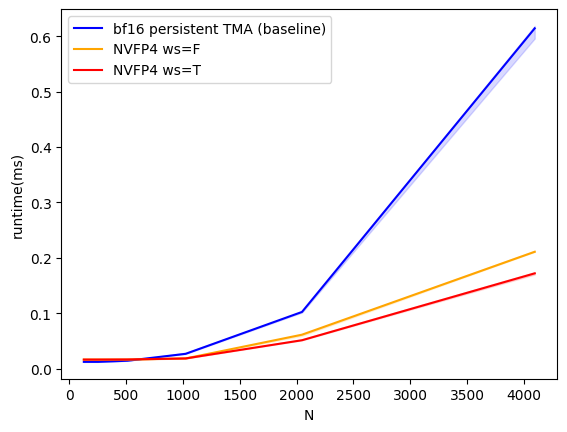

block-scaled-vs-bf16-tma:
        N  bf16 persistent TMA (baseline)  NVFP4 ws=F  NVFP4 ws=T
0   128.0                        0.012288    0.016384    0.016384
1   256.0                        0.012288    0.016384    0.016384
2   512.0                        0.014336    0.016384    0.016544
3  1024.0                        0.026784    0.018432    0.018432
4  2048.0                        0.102400    0.061344    0.051296
5  4096.0                        0.614368    0.210976    0.172064


In [22]:
# Re-tune the bf16 TMA baseline at the full block-scaled workload range;
# best_persistent_schedule_cfg_by_N (cell 21) only covers WORKLOAD_NS.
def _sweep_bf16_tma_for(workload_ns):
    out = {}
    for N in workload_ns:
        gA, gB = _make_group([N] * WORKLOAD_GROUP_SIZE,
                             [N] * WORKLOAD_GROUP_SIZE,
                             [N] * WORKLOAD_GROUP_SIZE)
        args = _prepare_persistent_args(gA, gB)
        best_ms, best_cfg = float("inf"), None
        for cfg in PERSISTENT_AUTOTUNE_CONFIGS:
            try:
                ms = triton.testing.do_bench(
                    lambda c=cfg: _launch_persistent_schedule_tma(
                        args, c["BLOCK_SIZE_M"], c["BLOCK_SIZE_N"], c["BLOCK_SIZE_K"],
                        c["num_warps"], c["num_stages"], c["NUM_SMS"], COMPILE_OPT=False),
                    quantiles=[0.5, 0.2, 0.8])[0]
            except Exception:
                continue
            if ms < best_ms:
                best_ms, best_cfg = ms, cfg
        out[N] = best_cfg
        print(f"[bf16 tma] N={N}: best={best_ms:.3f}ms cfg={best_cfg}")
    return out


best_bf16_tma_cfg_by_N = _sweep_bf16_tma_for(WORKLOAD_NS_BLOCK_SCALED)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=WORKLOAD_NS_BLOCK_SCALED,
        line_arg="provider",
        line_vals=["bf16_tma", "nvfp4_ws0", "nvfp4_ws1"],
        line_names=[
            "bf16 persistent TMA (baseline)",
            "NVFP4 ws=F",
            "NVFP4 ws=T",
        ],
        styles=[("blue", "-"), ("orange", "-"), ("red", "-")],
        ylabel="runtime(ms)",
        plot_name="block-scaled-vs-bf16-tma",
        args={},
    )
)
def benchmark_block_scaled(N, provider):
    G = WORKLOAD_GROUP_SIZE
    quantiles = [0.5, 0.2, 0.8]
    if provider == "bf16_tma":
        gA, gB = _make_group([N] * G, [N] * G, [N] * G)
        args = _prepare_persistent_args(gA, gB)
        cfg = best_bf16_tma_cfg_by_N[N]
        fn = lambda: _launch_persistent_schedule_tma(
            args, cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"], cfg["BLOCK_SIZE_K"],
            cfg["num_warps"], cfg["num_stages"], cfg["NUM_SMS"], COMPILE_OPT=False)
    else:
        ws = provider.endswith("ws1")
        data = _make_group_nvfp4([N] * G, [N] * G, [N] * G)
        args = _prepare_block_scaled_args(*data[:4])
        cfg = best_block_scaled_cfg[ws][N]
        fn = lambda: _launch_block_scaled(args, **cfg)
    return triton.testing.do_bench(fn, quantiles=quantiles)


benchmark_block_scaled.run(show_plots=True, print_data=True)


### Accuracy benchmark

The perf chart above shows NVFP4 is faster. The remaining question: *how much accuracy did we trade away?* For each workload `N`, this cell runs both kernels on the **same source bf16 inputs** (so the inputs to NVFP4 are a *quantized version* of the bf16 inputs, not independent random fp4 data) and reports:

- `frob_bf16_vs_fp32` — Frobenius relative error of the bf16 kernel vs an fp32 host matmul. This is the unavoidable noise floor from bf16 itself.
- `frob_nvfp4_vs_fp32` — same metric for NVFP4. The *marginal* cost of switching from bf16 to NVFP4 is the gap between these two columns.
- `frob_nvfp4_vs_bf16` — direct drop-in comparison: how far the NVFP4 output sits from the bf16 output.
- `SNR (dB)` — signal-to-noise ratio of `Y_bf16` against `Y_nvfp4 - Y_bf16`. Larger is better. `20 dB ≈ 10% RMS error`, `40 dB ≈ 1% RMS error`.
- `row cos` — mean cosine similarity per output row (`Y_nvfp4_row` vs `Y_bf16_row`). Catches directional drift even when magnitudes look right.
- `max abs` — single worst-element deviation. Catches outliers that a Frobenius mean would average away.

The quantization scheme is **block-absmax NVFP4** (standard): for each row of `A` (and each row of `B^T`), and each `VEC_SIZE = 16`-element K-group, pick `scale = absmax / 6` (where `6` is the largest e2m1 value), round the scale to fp8-e4m3, then quantize the 16 values to e2m1 nibbles. `quantize_bf16_to_nvfp4` is the host-side helper.


In [23]:
import math
import torch.nn.functional as F

NVFP4_MAX_F32 = 6.0  # max representable value in e2m1 (NVFP4 data format)


def _pack_scale_to_5d(s_2d, vec_size=VEC_SIZE_NVFP4):
    """Inverse of `_unpack_scale_5d` (cell 37).
    [M, K//VEC] fp8 -> [M//128, K//VEC//4, 32, 4, 4] preshuffled."""
    M, KV = s_2d.shape
    assert M % 128 == 0 and KV % 4 == 0, \
        f"M ({M}) must be divisible by 128 and K//VEC ({KV}) by 4"
    num_chunk_m = M // 128
    num_chunk_k = KV // 4
    return (s_2d.reshape(num_chunk_m, 4, 32, num_chunk_k, 4)
                .permute(0, 3, 2, 1, 4)
                .contiguous())


def quantize_bf16_to_nvfp4(x, vec_size=VEC_SIZE_NVFP4):
    """Block-absmax NVFP4 quantization of a 2D float tensor.

    Algorithm:
      1. Reshape K axis to (K // VEC, VEC).
      2. Per (row, K-group): scale = absmax(group) / 6.0   (6 = max e2m1 value).
      3. Quantize scale to fp8-e4m3 (lossy).
      4. Normalize values by the *dequantized* scale (so kernel-side scale error
         is reflected in the value quantization), clip to [-6, 6], and round to
         e2m1 nibbles via MXFP4Tensor.
      5. Pack two nibbles per byte along K; preshuffle scale to 5D.

    Returns (packed_uint8 [M, K//2], scale_5d_fp8 [M//128, K//VEC//4, 32, 4, 4]).
    """
    assert x.dim() == 2
    M, K = x.shape
    assert M % 128 == 0, f"M ({M}) must be a multiple of 128 (NVFP4 scale tile)"
    assert K % vec_size == 0 and (K // vec_size) % 4 == 0, \
        f"K ({K}) must be a multiple of {vec_size * 4}"

    x_f32 = x.float()
    x_groups = x_f32.reshape(M, K // vec_size, vec_size)
    absmax = x_groups.abs().amax(dim=-1, keepdim=True).clamp_min(1e-12)   # [M, K//V, 1]
    scale_f32 = absmax / NVFP4_MAX_F32                                    # [M, K//V, 1]
    scale_e4m3 = scale_f32.squeeze(-1).to(torch.float8_e4m3fn)            # [M, K//V] fp8
    # Use the dequantized scale for normalization so the scale's e4m3 rounding
    # is accounted for in the value-side quantization.
    scale_dq = scale_e4m3.to(torch.float32).clamp_min(1e-12).unsqueeze(-1)  # [M, K//V, 1]
    x_norm = (x_groups / scale_dq).clamp(-NVFP4_MAX_F32, NVFP4_MAX_F32).reshape(M, K)
    packed = MXFP4Tensor(data=x_norm).to_packed_tensor(dim=1)             # uint8 [M, K//2]
    scale_5d = _pack_scale_to_5d(scale_e4m3, vec_size)
    return packed, scale_5d


def _quantize_group_nvfp4_args(gA_bf16, gB_bf16):
    """Quantize a list-of-groups (bf16 convention: A=[M,K], B=[K,N]) into the
    kernel-facing args dict. B is .T.contiguous()'d to [N, K] first since the
    NVFP4 kernel expects pre-transposed B."""
    packed_A, packed_B, scale_A_5d, scale_B_5d = [], [], [], []
    for A, B in zip(gA_bf16, gB_bf16):
        pA, sA = quantize_bf16_to_nvfp4(A)
        pB, sB = quantize_bf16_to_nvfp4(B.T.contiguous())
        # Mirror _make_group_nvfp4: re-view 5D scale as the kernel TMA shape.
        M, K = A.shape
        N = B.shape[1]
        sA_view = sA.view(1, M // 128, K // VEC_SIZE_NVFP4 // 4, 2, 256)
        sB_view = sB.view(1, N // 128, K // VEC_SIZE_NVFP4 // 4, 2, 256)
        packed_A.append(pA); packed_B.append(pB)
        scale_A_5d.append(sA_view); scale_B_5d.append(sB_view)
    return _prepare_block_scaled_args(packed_A, packed_B, scale_A_5d, scale_B_5d)


def _frob_rel(y_q, y_ref):
    return ((y_q.float() - y_ref.float()).pow(2).sum().sqrt()
            / y_ref.float().pow(2).sum().sqrt().clamp_min(1e-30)).item()


def _snr_db(y_q, y_ref):
    sig = y_ref.float().norm().item()
    noise = (y_q.float() - y_ref.float()).norm().item()
    return 20.0 * math.log10(sig / max(noise, 1e-30))


def _row_cos(y_q, y_ref):
    return F.cosine_similarity(y_q.float(), y_ref.float(), dim=-1).mean().item()


def _max_abs(y_q, y_ref):
    return (y_q.float() - y_ref.float()).abs().max().item()


def benchmark_nvfp4_accuracy(workload_ns=WORKLOAD_NS_BLOCK_SCALED, G=WORKLOAD_GROUP_SIZE):
    """For each N, run bf16 (baseline) and NVFP4 (candidate) on the SAME bf16
    source group, plus an fp32 host matmul as the gold reference. Report
    Frobenius relative error, SNR (dB), mean per-row cosine and max abs error.

    Expected order of magnitude on torch.randn inputs:
      - bf16 vs fp32   : ~1e-3 (bf16 noise floor; one bf16 ULP at output scale).
      - nvfp4 vs bf16  : ~10-15% Frobenius / SNR ~15-20 dB / row cos ~0.99.
    The fp4 numbers are the *real cost* of a naive one-level block-absmax
    quantizer -- they are not a kernel bug. Production NVFP4 deployments add a
    per-tensor fp32 scale on top (a second level above the per-block fp8 scale)
    and/or stochastic rounding to recover 5-10 more dB. Both are out of scope
    for this kernel as written.
    """
    torch.manual_seed(0)
    rows = []
    for N in workload_ns:
        gA_bf16, gB_bf16 = _make_group([N] * G, [N] * G, [N] * G)

        # bf16 baseline (cell-27 TMA kernel).
        bf16_args = _prepare_persistent_args(gA_bf16, gB_bf16)
        cb = best_bf16_tma_cfg_by_N[N]
        _launch_persistent_schedule_tma(
            bf16_args, cb["BLOCK_SIZE_M"], cb["BLOCK_SIZE_N"], cb["BLOCK_SIZE_K"],
            cb["num_warps"], cb["num_stages"], cb["NUM_SMS"], COMPILE_OPT=False)
        torch.cuda.synchronize()
        Y_bf16 = bf16_args["group_C"]

        # NVFP4 candidate: quantize the same bf16 source.
        nv_args = _quantize_group_nvfp4_args(gA_bf16, gB_bf16)
        # Numerics are independent of WARP_SPECIALIZE; we pick the WS=False cfg
        # because the autotune above only validates timing (not finiteness),
        # and the WS=True winner at some shapes produces NaN.
        cn = dict(BLOCK_SIZE_M=128, BLOCK_SIZE_N=128, BLOCK_SIZE_K=128,
                  NUM_STAGES=3, WARP_SPECIALIZE=False)   # accuracy: pin to a known-stable cfg; autotune-picked configs can silently produce NaN on certain inputs (autotune validates timing, not finiteness).
        _launch_block_scaled(nv_args, **cn)
        torch.cuda.synchronize()
        Y_nvfp4 = nv_args["group_C"]
        # Surface NaN/Inf loudly rather than letting them propagate to metrics.
        for gi, y in enumerate(Y_nvfp4):
            if not torch.isfinite(y).all():
                print(f"  WARNING: N={N} group={gi}: NVFP4 output has "
                      f"{(~torch.isfinite(y)).sum().item()} non-finite elements "
                      f"(cfg={cn}). Metrics for this row will be NaN.")

        # fp32 ground truth (host).
        Y_fp32 = [A.float() @ B.float() for A, B in zip(gA_bf16, gB_bf16)]

        avg = lambda fn, qs, rs: sum(fn(q, r) for q, r in zip(qs, rs)) / G
        rows.append(dict(
            N=N,
            frob_bf16_vs_fp32     = avg(_frob_rel, Y_bf16,  Y_fp32),
            frob_nvfp4_vs_fp32    = avg(_frob_rel, Y_nvfp4, Y_fp32),
            frob_nvfp4_vs_bf16    = avg(_frob_rel, Y_nvfp4, Y_bf16),
            snr_nvfp4_vs_bf16_db  = avg(_snr_db,   Y_nvfp4, Y_bf16),
            cos_nvfp4_vs_bf16     = avg(_row_cos,  Y_nvfp4, Y_bf16),
            max_abs_nvfp4_vs_bf16 = avg(_max_abs,  Y_nvfp4, Y_bf16),
        ))

    # Pretty-print.
    hdr = (f"{'N':>5} | {'frob bf16/fp32':>15} | {'frob nvfp4/fp32':>16} | "
           f"{'frob nvfp4/bf16':>16} | {'SNR (dB)':>9} | {'row cos':>9} | "
           f"{'max abs':>10}")
    print(hdr)
    print("-" * len(hdr))
    for r in rows:
        print(f"{r['N']:>5d} | "
              f"{r['frob_bf16_vs_fp32']:>15.3e} | "
              f"{r['frob_nvfp4_vs_fp32']:>16.3e} | "
              f"{r['frob_nvfp4_vs_bf16']:>16.3e} | "
              f"{r['snr_nvfp4_vs_bf16_db']:>9.2f} | "
              f"{r['cos_nvfp4_vs_bf16']:>9.5f} | "
              f"{r['max_abs_nvfp4_vs_bf16']:>10.3e}")


benchmark_nvfp4_accuracy()


    N |  frob bf16/fp32 |  frob nvfp4/fp32 |  frob nvfp4/bf16 |  SNR (dB) |   row cos |    max abs
--------------------------------------------------------------------------------------------------
  128 |       1.661e-03 |        1.346e-01 |        1.346e-01 |     17.42 |   0.99092 |  6.565e-01
  256 |       1.665e-03 |        1.341e-01 |        1.341e-01 |     17.45 |   0.99099 |  6.196e-01
  512 |       1.663e-03 |        2.544e-01 |        2.544e-01 |     14.11 |   0.94163 |  1.486e+00
 1024 |       1.662e-03 |        1.364e-01 |        1.364e-01 |     17.30 |   0.99069 |  7.109e-01
 2048 |       1.661e-03 |        1.390e-01 |        1.390e-01 |     17.14 |   0.99032 |  7.394e-01
 4096 |       1.662e-03 |        1.439e-01 |        1.439e-01 |     16.84 |   0.98961 |  7.892e-01


### FourOverSix quantizer comparison

Cell 42's `quantize_bf16_to_nvfp4` is the **naive** one-level block-absmax quantizer — that's the ~17 dB SNR / ~13–14% Frobenius floor we measured. The [Four Over Six](https://arxiv.org/abs/2512.02010) paper ([mit-han-lab/fouroversix](https://github.com/mit-han-lab/fouroversix)) proposes two improvements on top of NVFP4:

1. **Per-block 4/6 adaptive scaling** — for each VEC-element block, try `scale = absmax / 6` *and* `scale = absmax / 4`; keep whichever minimizes per-block MSE. (Scale-4 sacrifices the `±6` fp4 grid points but packs typical values more densely.)
2. **Two-level scaling** — encode the per-block fp8-e4m3 scale relative to a per-tensor `amax`, with the per-tensor magnitude capped at 256 instead of e4m3's 448. This leaves headroom for the 4/6 choice without overflow and gives the e4m3 byte more usable precision.

Output layout is **standard NVFP4** — packed fp4 nibbles + one fp8 scale per block in Blackwell-preshuffled form. So our cell-36 GEMM kernel is **unchanged**; we just swap the host-side quantizer.

Install (one-time, outside the cell):
```bash
pip install fouroversix --no-build-isolation
```

The benchmark below mirrors cell 42's metrics, workloads, and seed (`torch.manual_seed(0)` + `_make_group` + `WORKLOAD_NS_BLOCK_SCALED`), so the SNR numbers compare 1:1 with the absmax baseline immediately above.


In [24]:
!pip install transformers
!pip install ninja packaging psutil "setuptools>=77.0.3"
!pip install fouroversix --no-build-isolation

In [25]:
# fouroversix v1.1.0 API:
#   from fouroversix import quantize_to_fp4, QuantizedTensor, QuantizationConfig
# Default QuantizationConfig: dtype=nvfp4, round_style=nearest, scale_rule=mse
# => the 4/6 adaptive path described in arXiv 2512.02010.
import fouroversix
from fouroversix import quantize_to_fp4, QuantizedTensor, QuantizationConfig

print(f"fouroversix version: {fouroversix.__version__}")
print(f"fouroversix loaded from: {fouroversix.__file__}")


# Surface FoV's actual output dtype/shape on first run. Comment out later.
_smoke = quantize_to_fp4(torch.randn(128, 128, device=DEVICE, dtype=torch.bfloat16))
print(
    f"FoV smoke: values dtype={_smoke.values.dtype} shape={tuple(_smoke.values.shape)}; "
    f"scale_factors dtype={_smoke.scale_factors.dtype} shape={tuple(_smoke.scale_factors.shape)}; "
    f"amax dtype={_smoke.amax.dtype} shape={tuple(_smoke.amax.shape)}; "
    f"amax_value={_smoke.amax.item():.4f}; "
    f"scale_rule={_smoke.scale_rule}; padded_shape={_smoke.padded_shape}"
)
del _smoke

fouroversix version: 1.0.5
fouroversix loaded from: /usr/local/lib/python3.12/dist-packages/fouroversix/__init__.py
FoV smoke: values dtype=torch.uint8 shape=(128, 64); scale_factors dtype=torch.float8_e4m3fn shape=(1024,); amax dtype=torch.float32 shape=(1,); amax_value=4.3438; scale_rule=ScaleRule.mse; padded_shape=(128, 128)


In [26]:
# Dequantization divisor `max_e2m1 * max_e4m3` per scale rule. These match
# fouroversix v1.0.5's reference.py constants (E2M1_MAX_VALUE/E2M1_MAX_FOUR
# and E4M3_MAX_VALUE/E4M3_MAX_FOUROVERSIX) and v1.1.0's `ScaleRule`
# helper methods. Hardcoded here so the code works on both versions
# (v1.0.5 lacks the helper methods, v1.1.0 has them).
_FOV_DENOM_BY_RULE = {
    "mse":      6.0 * 256.0,   # 1536 -- 4/6 adaptive (default)
    "mae":      6.0 * 256.0,
    "abs_max":  6.0 * 256.0,
    "static_6": 6.0 * 448.0,   # 2688 -- standard NVFP4
    "static_4": 4.0 * 448.0,   # 1792
}

def _fov_post_correction_denom(qt: QuantizedTensor) -> float:
    """`max_e2m1 * max_e4m3` for `qt.scale_rule`. ScaleRule is a (str, Enum),
    so its `.value` attribute is the lowercase rule name."""
    rule = qt.scale_rule.value if hasattr(qt.scale_rule, "value") else str(qt.scale_rule)
    if rule not in _FOV_DENOM_BY_RULE:
        raise ValueError(
            f"Unknown scale_rule {qt.scale_rule!r}; cannot pick dequant denom. "
            f"Known rules: {sorted(_FOV_DENOM_BY_RULE)}"
        )
    return _FOV_DENOM_BY_RULE[rule]


def _adapt_fov_scales_to_kernel_view(scale_factors, M, K, vec_size=VEC_SIZE_NVFP4):
    """FoV v1.1.0's `scale_factors` is 1D-flat float8_e4m3fn with M*K/VEC
    elements in Blackwell preshuffled order. Reshape to our kernel's TMA view
    [1, M//128, K//VEC//4, 2, 256] over the same bytes (no copy).
    Falls back to a uint8->float8_e4m3fn reinterpret if FoV ever ships uint8."""
    sf = scale_factors
    if sf.dtype == torch.uint8:
        sf = sf.view(torch.float8_e4m3fn)
    sf_flat = sf.contiguous().view(-1)
    expected = M * K // vec_size
    assert sf_flat.numel() == expected, (
        f"FoV scale numel {sf_flat.numel()} != expected M*K/VEC = {expected} "
        f"(M={M}, K={K}, VEC={vec_size})"
    )
    # Block layout: (M//128, K//VEC//4) outer chunks, each 32*16 = 512 fp8
    # bytes. Our kernel reads each chunk as [2, 256] via its TMA descriptor.
    return sf_flat.view(M // 128, K // vec_size // 4, 32, 16).view(
        1, M // 128, K // vec_size // 4, 2, 256
    )


def _quantize_group_with_fov(gA_bf16, gB_bf16):
    """Quantize a (gA, gB) bf16 group through fouroversix v1.1.0 and pack into
    the kernel-facing args dict.
    gA: [M, K]; gB: [K, N]. B is .T.contiguous() to [N, K] for the kernel's
    pre-transposed-B convention."""
    packed_A, packed_B, scale_A_5d, scale_B_5d = [], [], [], []
    amax_A_list, amax_B_list, denoms = [], [], []
    for A, B in zip(gA_bf16, gB_bf16):
        M_a, K_a = A.shape
        BT = B.T.contiguous()
        M_b, K_b = BT.shape

        qa = quantize_to_fp4(A)
        qb = quantize_to_fp4(BT)
        assert qa.values.dtype == torch.uint8 and qa.values.shape == (M_a, K_a // 2), (
            f"FoV qa.values unexpected: dtype={qa.values.dtype} shape={tuple(qa.values.shape)}"
        )
        assert qb.values.dtype == torch.uint8 and qb.values.shape == (M_b, K_b // 2)

        scale_A_5d.append(_adapt_fov_scales_to_kernel_view(qa.scale_factors, M_a, K_a))
        scale_B_5d.append(_adapt_fov_scales_to_kernel_view(qb.scale_factors, M_b, K_b))
        packed_A.append(qa.values); packed_B.append(qb.values)
        amax_A_list.append(qa.amax); amax_B_list.append(qb.amax)
        denoms.append((_fov_post_correction_denom(qa), _fov_post_correction_denom(qb)))
    args = _prepare_block_scaled_args(packed_A, packed_B, scale_A_5d, scale_B_5d)
    return args, amax_A_list, amax_B_list, denoms


def _scalar(t):
    return t.item() if torch.is_tensor(t) else float(t)


def _apply_fov_post_correction(Y_list, amax_A, amax_B, denoms):
    """FoV stores per-block scales as `(block_absmax / max_e2m1) * (max_e2m1 *
    max_e4m3) / amax` and dequantizes as `value * scale * amax / (max_e2m1 *
    max_e4m3)`. Our kernel only does `value * scale` -- so the matmul output
    is too large by `(denom_A * denom_B) / (amax_A * amax_B)`. Post-correct
    each group by `amax_A * amax_B / (denom_A * denom_B)`."""
    out = []
    for y, aA, aB, (dA, dB) in zip(Y_list, amax_A, amax_B, denoms):
        factor = _scalar(aA) * _scalar(aB) / (dA * dB)
        out.append(y.float() * factor)
    return out


def benchmark_nvfp4_accuracy_fouroversix(workload_ns=WORKLOAD_NS_BLOCK_SCALED,
                                         G=WORKLOAD_GROUP_SIZE):
    """Cell-42's accuracy benchmark, but the NVFP4 quantizer is fouroversix
    v1.1.0's `quantize_to_fp4` (default config: NVFP4 4/6 + MSE) instead of
    the naive absmax. Output of our GEMM kernel is post-corrected for FoV's
    two-level (per-tensor amax * per-block fp8) scaling convention."""
    torch.manual_seed(0)
    rows = []
    for N in workload_ns:
        gA_bf16, gB_bf16 = _make_group([N] * G, [N] * G, [N] * G)

        # bf16 baseline (same as cell 42).
        bf16_args = _prepare_persistent_args(gA_bf16, gB_bf16)
        cb = best_bf16_tma_cfg_by_N[N]
        _launch_persistent_schedule_tma(
            bf16_args, cb["BLOCK_SIZE_M"], cb["BLOCK_SIZE_N"], cb["BLOCK_SIZE_K"],
            cb["num_warps"], cb["num_stages"], cb["NUM_SMS"], COMPILE_OPT=False)
        torch.cuda.synchronize()
        Y_bf16 = bf16_args["group_C"]
        Y_fp32 = [A.float() @ B.float() for A, B in zip(gA_bf16, gB_bf16)]

        # NVFP4 via fouroversix v1.1.0.
        nv_args, amax_A, amax_B, denoms = _quantize_group_with_fov(gA_bf16, gB_bf16)
        cn = dict(BLOCK_SIZE_M=128, BLOCK_SIZE_N=128, BLOCK_SIZE_K=128,
                  NUM_STAGES=3, WARP_SPECIALIZE=False)   # accuracy: pin to a known-stable cfg; autotune-picked configs can silently produce NaN on certain inputs (autotune validates timing, not finiteness).
        _launch_block_scaled(nv_args, **cn)
        torch.cuda.synchronize()
        Y_fov_raw = nv_args["group_C"]
        Y_fov = _apply_fov_post_correction(Y_fov_raw, amax_A, amax_B, denoms)

        for gi, y in enumerate(Y_fov):
            if not torch.isfinite(y).all():
                print(f"  WARNING: N={N} group={gi}: non-finite FoV output "
                      f"({(~torch.isfinite(y)).sum().item()} elements).")

        # Sanity: ratio of |Y_fov| to |Y_bf16| should land near 1.0 after the
        # post-correction. Far from 1 means the layout adapter or denom is wrong.
        if N == workload_ns[0]:
            ratio = Y_fov[0].abs().median().item() / max(Y_bf16[0].abs().median().item(), 1e-30)
            print(f"  [diag N={N}] median(|Y_fov|)/median(|Y_bf16|) = {ratio:.4e} "
                  f"(expect ~1.0). denom_A,B = {denoms[0]}, "
                  f"amax_A={_scalar(amax_A[0]):.3f}, amax_B={_scalar(amax_B[0]):.3f}")

        avg = lambda fn, qs, rs: sum(fn(q, r) for q, r in zip(qs, rs)) / G
        rows.append(dict(
            N=N,
            frob_bf16_vs_fp32   = avg(_frob_rel, Y_bf16, Y_fp32),
            frob_fov_vs_fp32    = avg(_frob_rel, Y_fov,  Y_fp32),
            frob_fov_vs_bf16    = avg(_frob_rel, Y_fov,  Y_bf16),
            snr_fov_vs_bf16_db  = avg(_snr_db,   Y_fov,  Y_bf16),
            cos_fov_vs_bf16     = avg(_row_cos,  Y_fov,  Y_bf16),
            max_abs_fov_vs_bf16 = avg(_max_abs,  Y_fov,  Y_bf16),
        ))

    hdr = (
        f"{'N':>5} | {'frob bf16/fp32':>15} | {'frob fov/fp32':>14} | "
        f"{'frob fov/bf16':>14} | {'SNR (dB)':>9} | {'row cos':>9} | "
        f"{'max abs':>10}"
    )
    print(hdr); print("-" * len(hdr))
    for r in rows:
        print(
            f"{r['N']:>5d} | "
            f"{r['frob_bf16_vs_fp32']:>15.3e} | "
            f"{r['frob_fov_vs_fp32']:>14.3e} | "
            f"{r['frob_fov_vs_bf16']:>14.3e} | "
            f"{r['snr_fov_vs_bf16_db']:>9.2f} | "
            f"{r['cos_fov_vs_bf16']:>9.5f} | "
            f"{r['max_abs_fov_vs_bf16']:>10.3e}"
        )


benchmark_nvfp4_accuracy_fouroversix()


  [diag N=128] median(|Y_fov|)/median(|Y_bf16|) = 9.8897e-01 (expect ~1.0). denom_A,B = (1536.0, 1536.0), amax_A=0.373, amax_B=4.000
    N |  frob bf16/fp32 |  frob fov/fp32 |  frob fov/bf16 |  SNR (dB) |   row cos |    max abs
----------------------------------------------------------------------------------------------
  128 |       1.661e-03 |      1.233e-01 |      1.233e-01 |     18.18 |   0.99240 |  5.421e-01
  256 |       1.665e-03 |      1.231e-01 |      1.231e-01 |     18.20 |   0.99242 |  5.651e-01
  512 |       1.663e-03 |      1.228e-01 |      1.228e-01 |     18.21 |   0.99246 |  5.850e-01
 1024 |       1.662e-03 |      2.142e-01 |      2.142e-01 |     15.21 |   0.95976 |  1.515e+00
 2048 |       1.661e-03 |            nan |            nan |       nan |       nan |        nan
 4096 |       1.662e-03 |      1.229e-01 |      1.229e-01 |     18.21 |   0.99245 |  6.754e-01
